
---
# Lab. Movilidad, representación geográfica y visualización

## Máster Inteligencia Artificial Aplicada
### Asignatura: Ciudades inteligentes
#### Profesora: Patricia Callejo
#### Alumno: Emilio Hermosa Schiantarelli, 100451150@alumnos.uc3m.es
---

En esta práctica aprenderemos a utilizar datos geoespaciales, contaremos con una base de datos de movilidad de viajes de taxi en la ciudad de Nueva York y realizaremos un ejercicio de predicción de coste de rutas utilizando técnicas de machine learning. Además representaremos los resultados en mapas para aprender a manejar los datos geoespaciales.

Por último aprenderemos a crear un dashboard para poner todos los resultados.

Vamos a ello!


### Paso 1: Descargar los datos

Los datos han sido descargados de este challenge de [Kaggle](https://www.kaggle.com/competitions/new-york-city-taxi-fare-prediction/data) aunque debido a las limitaciones de la versión gratuita de Google Colab, se ha seleccionado un random sample de 100000 entradas de ese dataset. Esta preselección será la que utilicemos en esta práctica, para los fines de la misma serán más que suficientes. Si se quiere por cuenta ajena trabajar con el dataset completo (55M de datos), se puede descargar de Kaggle.  

Por tanto, los datos que se utilizarán están disponibles en Aula Global bajo el nombre: *data-NYC-taxi-fare.csv*

Este CSV contiene los siguientes campos:

*  **key:** *`string`* único que identifica cada fila. Compuesta por la fecha y hora de recogida más un número entero único, pero esto no importa, solo se debe usar como un campo de ID único.
*  **pickup_datetime:** *`timestamp`* que indica cuándo comenzó el viaje en taxi.
*  **pickup_longitude:** *`float`* que representa la coordenada de longitud donde comenzó el viaje en taxi.
*  **pickup_latitude:** *`float`* que representa la coordenada de latitud donde comenzó el viaje en taxi.
*  **dropoff_longitude:** *`float`* que representa la coordenada de longitud donde terminó el viaje en taxi.
*  **dropoff_latitude:** *`float`* que representa la coordenada de latitud donde terminó el viaje en taxi.
*  **passenger_count:** *`integer`* que indica el número de pasajeros en el viaje en taxi.
*  **fare_amount:** *`float`* coste en dólares del viaje en taxi.
* **trip_distance_km:** *`float`* distancia del trayecto calculado con la distancia Haversine.

**NOTA IMPORTANTE**: Aunque el notebook estaba preparado para ser ejecutado inicialmente en Google Collab, se ha decidido realizar en local. Por esta razón se han comentado las dos siguientes celdas para evitar errores de ejecución.

In [38]:
# Sube los datos a tu Drive y accede a ellos desde el código dando acceso a Drive.
#from google.colab import drive
#drive.mount('/content/drive')

In [39]:
#Indicar la ruta a los datos y localizar el directorio de trabajo ahí con el siguiente comando (modificado)
#cd drive/MyDrive/...<PATH AL CSV>

### Paso 2: Instalar e importar las librerias necesarias para la práctica

A continuación se indican las librerías que son imprescindibles para el desarrollo de esta práctica, en concreto hay que instalar la librería *`h3`* que se utilizara para el desarrollo de la misma.  

In [40]:
# Install:
%pip install h3pandas panel mapclassify

import numpy as np
import pandas as pd
import matplotlib
import matplotlib.pyplot as plt
import seaborn as sns
import folium as folium
import h3pandas
import h3
from folium.plugins import MarkerCluster, HeatMap
import datetime
from sklearn.linear_model import LinearRegression, Ridge
from sklearn.tree import DecisionTreeRegressor
from sklearn.model_selection import RandomizedSearchCV
from sklearn.ensemble import GradientBoostingRegressor, RandomForestRegressor
from xgboost import XGBRegressor
from lightgbm import LGBMRegressor

# Importar librerias para el modelo utilizado
from sklearn.model_selection import train_test_split
from sklearn.ensemble import GradientBoostingRegressor, RandomForestRegressor
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
from sklearn.preprocessing import StandardScaler
from math import radians, cos, sin, asin, sqrt
import warnings
warnings.filterwarnings('ignore')



[notice] A new release of pip is available: 24.3.1 -> 26.0.1
[notice] To update, run: pip install --upgrade pip
Note: you may need to restart the kernel to use updated packages.


### Paso 3: Análisis de los datos

En este paso se espera que el alumno haga un análisis descriptivo de los datos disponibles. Para entender mejor los datos, pintar la distribución de los mismos en base a los años, a los meses, cual es el la distribución de las distancias, de los costes, etc.

In [41]:
df = pd.read_csv("data-NYC-taxi-fare.csv")
df.head()

,key,fare_amount,pickup_datetime,pickup_longitude,pickup_latitude,dropoff_longitude,dropoff_latitude,passenger_count,trip_distance_km
0,2011-05-31 22:21:01.0000004,7.3,2011-05-31 22:21:01,-73.994009,40.761440,-73.972811,40.792574,1,3.895004
1,2011-05-11 13:26:00.0000007,14.1,2011-05-11 13:26:00,-73.976888,40.787700,-73.967403,40.761462,2,3.024882
2,2015-02-12 16:37:31.0000002,6.0,2015-02-12 16:37:31,-74.003326,40.720531,-74.008217,40.716930,1,0.574636
3,2012-03-28 21:05:00.000000196,19.3,2012-03-28 21:05:00,-73.999330,40.722333,-73.935865,40.684185,1,6.827491
4,2010-08-07 06:07:30.0000002,8.1,2010-08-07 06:07:30,-73.965385,40.761611,-73.991350,40.749571,1,2.564272


#### Autocompletar

Aunque estéticamente no sea lo mejor, se ha decidido mantener estos titulos para que sea más fácil discernir entre lo que estaba ya hecho y lo que se me pedía hacer para la práctica.

#### 3.1 Información general del dataset

Es importante remarcar que dependiendo del problema y del objetivo del EDA, este se puede hacer sobre todo el dataset o únicamente sobre el set que se va a utilizar para el posterior entrenamiento del modelo, aislando el set de evaluación del análisis descriptivo inicial de las transformaciones. Se ha acabado concretando junto a la profsora que para los objetivos de esta práctica, un análisis descriptivo del dataset completo es más adecuado en este caso. Para luego el entrenamiento del modelo solo se tratan los datos del set de entrenamiento y se dejan los del test sin modificar para validar el modelo.

Se comienza explorando la estructura y tipos de datos del dataset de manera general.

In [42]:
# Información general del dataset
print(f'Dimensiones del dataset: {df.shape}')
print(f'\nNúmero de filas: {df.shape[0]}')
print(f'Número de columnas: {df.shape[1]}')
print(f'\nColumnas: {list(df.columns)}')
print(f'\nTipos de datos:')
print(df.dtypes)
print(f'\nValores nulos por columna:')
print(df.isnull().sum())
print(f'\nEstadísticas descriptivas:')
df.describe()


Dimensiones del dataset: (99998, 9)

Número de filas: 99998
Número de columnas: 9

Columnas: ['key', 'fare_amount', 'pickup_datetime', 'pickup_longitude', 'pickup_latitude', 'dropoff_longitude', 'dropoff_latitude', 'passenger_count', 'trip_distance_km']

Tipos de datos:
key                      str
fare_amount          float64
pickup_datetime          str
pickup_longitude     float64
pickup_latitude      float64
dropoff_longitude    float64
dropoff_latitude     float64
passenger_count        int64
trip_distance_km     float64
dtype: object

Valores nulos por columna:
key                  0
fare_amount          0
pickup_datetime      0
pickup_longitude     0
pickup_latitude      0
dropoff_longitude    0
dropoff_latitude     0
passenger_count      0
trip_distance_km     0
dtype: int64

Estadísticas descriptivas:


,fare_amount,pickup_longitude,pickup_latitude,dropoff_longitude,dropoff_latitude,passenger_count,trip_distance_km
count,99998.000000,99998.000000,99998.000000,99998.000000,99998.000000,99998.000000,99998.000000
mean,11.356328,-72.540721,39.929845,-72.521448,39.933438,1.683554,19.442820
std,9.859857,10.807517,6.045585,10.394846,6.153573,1.307752,369.536529
min,0.000000,-739.983332,-74.004435,-273.960312,-74.177530,0.000000,0.000000
25%,6.000000,-73.991960,40.735127,-73.991420,40.733908,1.000000,1.214790
50%,8.500000,-73.981758,40.752832,-73.980190,40.753187,1.000000,2.121418
75%,12.500000,-73.967012,40.767210,-73.963912,40.768021,2.000000,3.883494
max,322.270000,40.804500,73.863840,40.800757,404.050000,9.000000,14362.076956


Se ha decidido realizar en primer lugar un análisis básico del dataset para conocer la cantidad de filas y columnas existentes, así como el tipo de datos y la cantidad de valores faltantes por columna. Por último se han querido ver las estadísticas más comunes en un EDA de cada columna (media, conteo, mínimos y máximos, etc.). 

Aunque ya se nos había dado una breve explicación de las columas del dataset al inicio del cuaderno, se ha creído conveniente partir de este análisis inicial para obtener una idea básica del dataset.

Gracias a este análisis se ha podido determinar que no existen valores NaN en ninguna columna del dataset por lo que no hará falta encargarse de valores faltantes.

Por otro lado sí se han visto ciertos puntos que hay que tener en cuenta y deben ser tratados sobre el dataset gracias a este análisis exploratorio inicial. En primer lugar, se ha podido ver como los datos de **pickup_datetime** son de tipo **str**, por lo que se ha decidido que se van a transformar a formato **datetime** ya que es más adecuado para este tipo de datos.

El segundo punto interesante que se ha encontrado es que hay viajes con coste 0$ lo cual se puede asumir que son datos erróneos. El máximo de costo de un viaje es de 322$ cuando el valor de los percentiles es mucho más bajo y la media es 11.3$ (la cuál ya es más elevada de lo que debería debido al posible outlier), lo cuál da indicios de posibles outliers en esta columna, así que se va a tener que analizar la posible existencia de valores atípicos en la misma.


Del mismo modo, hay otros viajes con 0 pasajeros (probablemente dato erróneo) o incluso 9 pasajeros. Dado que los percentiles están muy por debajo de ese valor y la media de pasajeros es de 1.7 se puede asumir que hay riesgo de que sean datos atípicos (para el caso de 9 pasajeros) o inválidos (para el caso de 0) y se va a tener que prestar atención ante esta posibilidad también durante el EDA.

Otra columna que se sospecha que tiene outliers es **trip_distance_km** ya que su máximo es de 14362km, un valor mucho mayor que los valores de los percentiles o la media. También se puede apreciar un valor de 0 para la distancia mínima, lo cuál no es posible.

El último punto importante a remrcar es la presencia de valores ficticios para latitudes y longitudes. Las latitudes y longitudes son coordenadas que se definen en estos intervalos:
- Latitud: de -90° a +90° (polo sur a polo norte)
- Longitud: de -180° a +180° (meridiano de Greenwich como referencia)

En los valores mínimos y máximos de latitud y longitud se pueden ver valores que superan estos intervalos como valores mínimos de **pickup_longitude** o de **dropoff_longitude** de **-739.983332** o **-273.960312** o máximos como el de **dropoff latitude** de **404.05**. Estos valores seguramente sean los que generan valores máximos de **trip_distance_km** como **14362.076956**.

Por lo tanto durante el análisis exploratorio de datos se van a analizar estos casos para determinar la mejor manera de transformar y tratar los datos para el posterior entrenamiento del modelo.

#### 3.2 Extracción de características temporales

Dado que se nos pide explícitamente al inicio del apartado hacer un análisis de los datos respecto a los años, meses distribución de distancias, etc. He decidido comenzar con eso para luego profundizar en las casuísticas que he descrito en el paso anterior.

Se extrae año, mes, día de la semana y hora del viaje para el análisis.

Dado que **pickup_datetime** es una fecha, se ha decidido que el modelo lo trate con formato fecha en vez de como **str**, por lo tanto es la primera transformación que se hace. Para evitar problemas, esta transformación se debe hacer a nivel del dataset completo dado que si solo se hiciera en el set de entrenamiento, el modelo daría error al intentar procesar **str** como fechas para el set de evaluación. 

También se van a crear columnas particulares para el año, el mes, el día y la hora de **pickup_datetime** intentando así que el modelo a desarrollar en apartados posteriores tenga la posibilidad de capturar patrones individuales de cada característica. Dado que este cambio no afecta directamente al valor de columnas sino que simplemente consiste en descomponer información de una columna ya existente en columnas con información particular, se hace a nivel global del dataset también. Al igual que para la transformación de la columna **pickup_datetime** en tipo **datetime**, si se crean solo las columnas nuevas en el set de entrenamiento, a la hora de evaluar  con el set de evaluación, dará un error, dado que el modelo esperará encontrarse las columnas nuevas también en el set de evaluación para poder predecir. Es por todo esto por lo que que estas transformaciones se hacen a nivel de dataset global.

In [43]:
# Extraer componentes temporales
df['pickup_datetime'] = pd.to_datetime(df['pickup_datetime'], format='mixed', utc=True)
df['year'] = df['pickup_datetime'].dt.year
df['month'] = df['pickup_datetime'].dt.month
df['day_of_week'] = df['pickup_datetime'].dt.dayofweek
df['hour'] = df['pickup_datetime'].dt.hour

# Mapeo de días de la semana
day_names = {0: 'Lunes', 1: 'Martes', 2: 'Miércoles', 3: 'Jueves', 4: 'Viernes', 5: 'Sábado', 6: 'Domingo'}
df['day_name'] = df['day_of_week'].map(day_names)

print('Rango temporal del dataset:')
print(f'  Desde: {df["pickup_datetime"].min()}')
print(f'  Hasta: {df["pickup_datetime"].max()}')
print(f'\nDistribución por año:')
print(df['year'].value_counts().sort_index())


Rango temporal del dataset:
  Desde: 2009-01-01 02:07:39+00:00
  Hasta: 2015-06-30 23:34:59+00:00

Distribución por año:
year
2009    15489
2010    15112
2011    15654
2012    16117
2013    15612
2014    15040
2015     6974
Name: count, dtype: int64


#### 3.3 Distribución de viajes por año


Esta sección sirve para comprobar si sigue alguna distribución la cantidad de viajes en base al año.

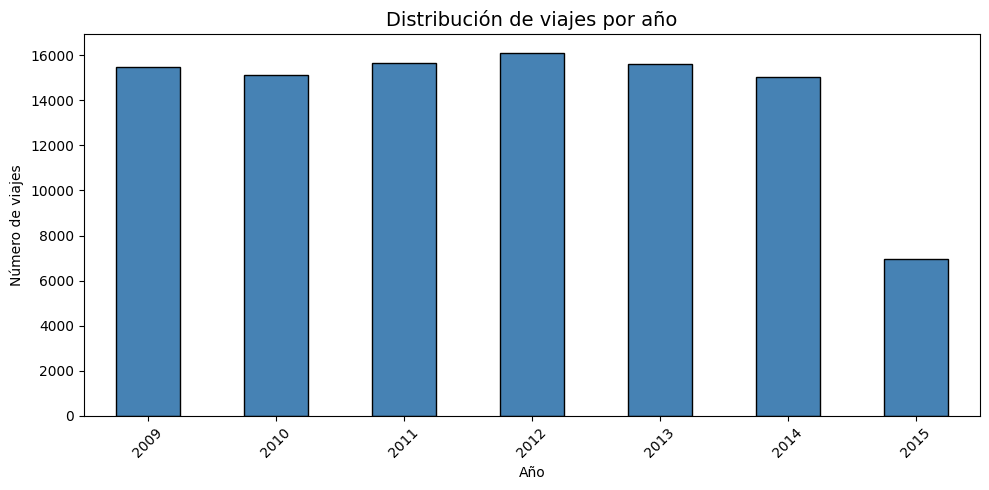

In [44]:
fig, ax = plt.subplots(figsize=(10, 5))
df['year'].value_counts().sort_index().plot(kind='bar', ax=ax, color='steelblue', edgecolor='black')
ax.set_title('Distribución de viajes por año', fontsize=14)
ax.set_xlabel('Año')
ax.set_ylabel('Número de viajes')
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()


Esto nos indica que existe cierta consistencia en la cantidad de viajes en taxi por año (2015 solo tiene la mitad del año en el dataset).

#### 3.4 Distribución de viajes por mes

Esta sección sirve para comprobar si sigue alguna distribución la cantidad de viajes en base a los meses del año.

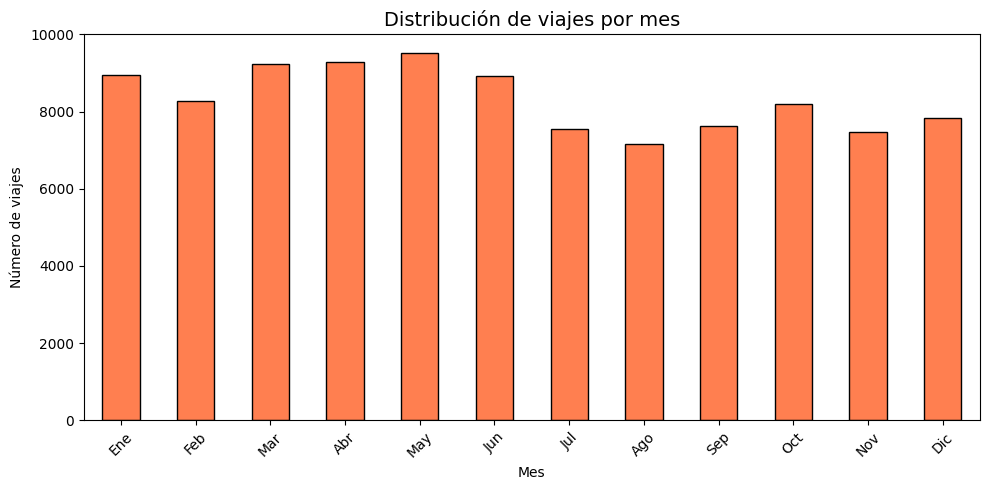

In [45]:
fig, ax = plt.subplots(figsize=(10, 5))
month_names = {1:'Ene', 2:'Feb', 3:'Mar', 4:'Abr', 5:'May', 6:'Jun',
               7:'Jul', 8:'Ago', 9:'Sep', 10:'Oct', 11:'Nov', 12:'Dic'}
month_counts = df['month'].value_counts().sort_index()
month_counts.index = [month_names[m] for m in month_counts.index]
month_counts.plot(kind='bar', ax=ax, color='coral', edgecolor='black')
ax.set_title('Distribución de viajes por mes', fontsize=14)
ax.set_xlabel('Mes')
ax.set_ylabel('Número de viajes')
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()


Mientras que el primer semestre del año se superan generalmente los 8000 viajes, para el segundo semestre apenas se llegan a los 8000 viajes.

#### 3.5 Distribución de viajes por día de la semana


Esta distribución nos permite ver los patrones de movilidad por día de semana. De esta forma se puede comprobar si sigue alguna distribucióon en el número de viajes en función de los días de la semana.

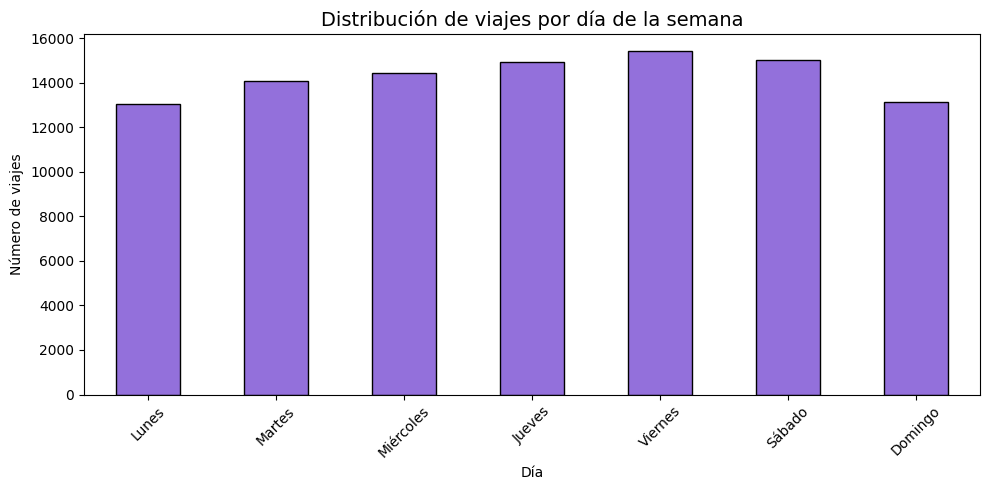

In [46]:
fig, ax = plt.subplots(figsize=(10, 5))
order = ['Lunes', 'Martes', 'Miércoles', 'Jueves', 'Viernes', 'Sábado', 'Domingo']
day_counts = df['day_name'].value_counts().reindex(order)
day_counts.plot(kind='bar', ax=ax, color='mediumpurple', edgecolor='black')
ax.set_title('Distribución de viajes por día de la semana', fontsize=14)
ax.set_xlabel('Día')
ax.set_ylabel('Número de viajes')
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()


Existe cierta linealidad para la cantidad de viajes por día de la semana.

#### 3.6 Distribución de viajes por hora del día
Esta distribución nos permite ver los patrones de movilidad: horas punta (mañana y tarde) y horas menos comunes (madrugada).

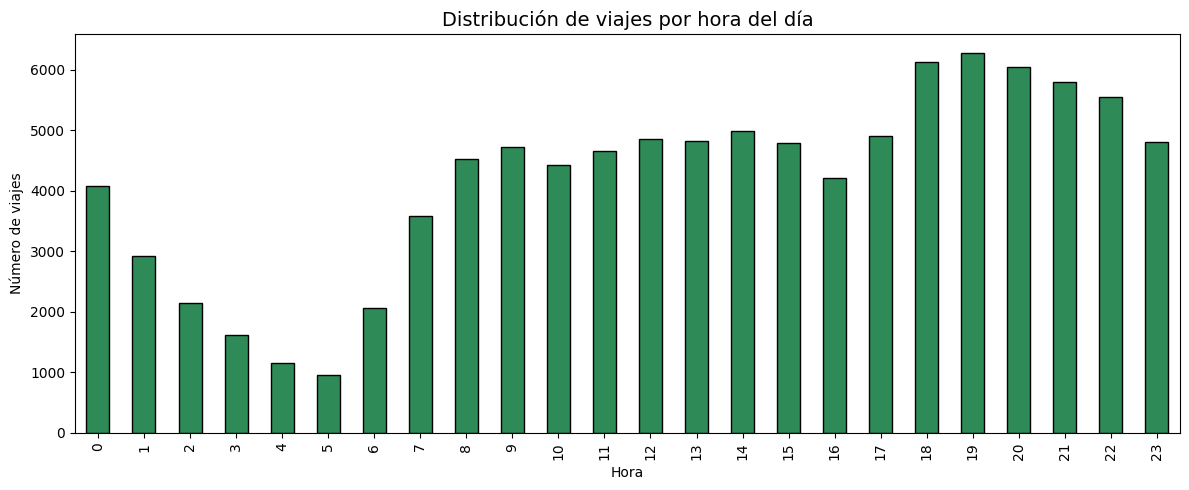

In [47]:
fig, ax = plt.subplots(figsize=(12, 5))
df['hour'].value_counts().sort_index().plot(kind='bar', ax=ax, color='seagreen', edgecolor='black')
ax.set_title('Distribución de viajes por hora del día', fontsize=14)
ax.set_xlabel('Hora')
ax.set_ylabel('Número de viajes')
plt.tight_layout()
plt.show()


En esta gráfica también se nota una disparidad en el número de viajes. Mientras que a altas horas de la madrugada casi no hay viajes, a medida que pasa el día aumenta la cantidad de viajes alcanzando su pico a las 19:00 y volviendo a descender poco a poco por la noche. Esto es normal dado que a sobre las 19:00 es cuando la gente suele salir de trabajar mientras que a altas horas de la madrugada las personas suelen estar durmiendo.

#### 3.7 Distribución de distancias y costes


Esta distribución nos permite ver uno de los puntos que se mencionaba en el **Apartado 3.1**. Se va a poder ver reflejada en esta sección la posible existencia de outliers en los costes y en las distancias de los viajes.

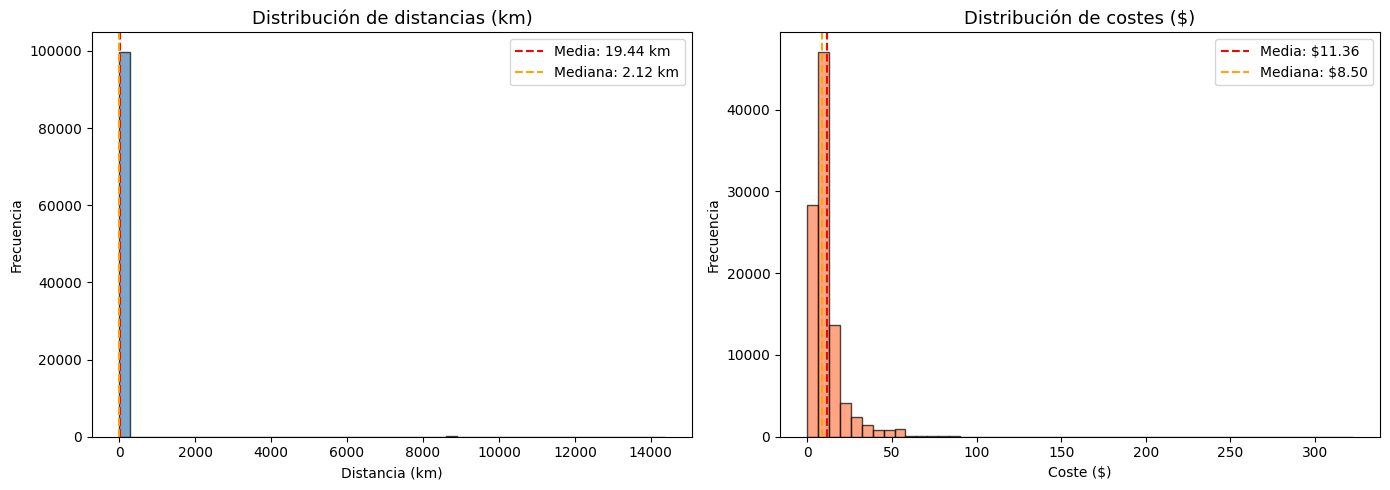

Estadísticas de distancia:
  Media: 19.44 km
  Mediana: 2.12 km
  Máx: 14362.08 km

Estadísticas de coste:
  Media: $11.36
  Mediana: $8.50
  Máx: $322.27


In [48]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Distribución de distancias
axes[0].hist(df['trip_distance_km'], bins=50, color='steelblue', edgecolor='black', alpha=0.7)
axes[0].set_title('Distribución de distancias (km)', fontsize=13)
axes[0].set_xlabel('Distancia (km)')
axes[0].set_ylabel('Frecuencia')
axes[0].axvline(df['trip_distance_km'].mean(), color='red', linestyle='--', label=f'Media: {df["trip_distance_km"].mean():.2f} km')
axes[0].axvline(df['trip_distance_km'].median(), color='orange', linestyle='--', label=f'Mediana: {df["trip_distance_km"].median():.2f} km')
axes[0].legend()

# Distribución de costes
axes[1].hist(df['fare_amount'], bins=50, color='coral', edgecolor='black', alpha=0.7)
axes[1].set_title('Distribución de costes ($)', fontsize=13)
axes[1].set_xlabel('Coste ($)')
axes[1].set_ylabel('Frecuencia')
axes[1].axvline(df['fare_amount'].mean(), color='red', linestyle='--', label=f'Media: ${df["fare_amount"].mean():.2f}')
axes[1].axvline(df['fare_amount'].median(), color='orange', linestyle='--', label=f'Mediana: ${df["fare_amount"].median():.2f}')
axes[1].legend()

plt.tight_layout()
plt.show()

print(f'Estadísticas de distancia:')
print(f'  Media: {df["trip_distance_km"].mean():.2f} km')
print(f'  Mediana: {df["trip_distance_km"].median():.2f} km')
print(f'  Máx: {df["trip_distance_km"].max():.2f} km')

print(f'\nEstadísticas de coste:')
print(f'  Media: ${df["fare_amount"].mean():.2f}')
print(f'  Mediana: ${df["fare_amount"].median():.2f}')
print(f'  Máx: ${df["fare_amount"].max():.2f}')


Estas dos gráficas son realmente interesantes para el posterior tratamientos de datos que se debe hacer ya que en ellas se pueden observar lo que ya se especulaba sobre la presencia de outliers (aunque a nivel del ojo humano no se puede ver la cantidad de casos, el hecho de que en la primera gráfica llegue a 14000km y la segunda a un coste de 300$ indica que ahí como mínimo hay uno). Por lo tanto, se deben tratar los outliers de costes y distancias para que el modelo no se vea luego afectado por ellos.

#### 3.8 Distribución de número de pasajeros


En esta distribución se va a poder resolver el otro problema de outliers que se percibía y mencionaba en el **Apartado 3.1** sobre el número de pasajeros. Con esta representación podré confirmar las sospechas de la existencia de casos inválidos con 0 pasajeros o casos atípicos con 9 pasajeros.

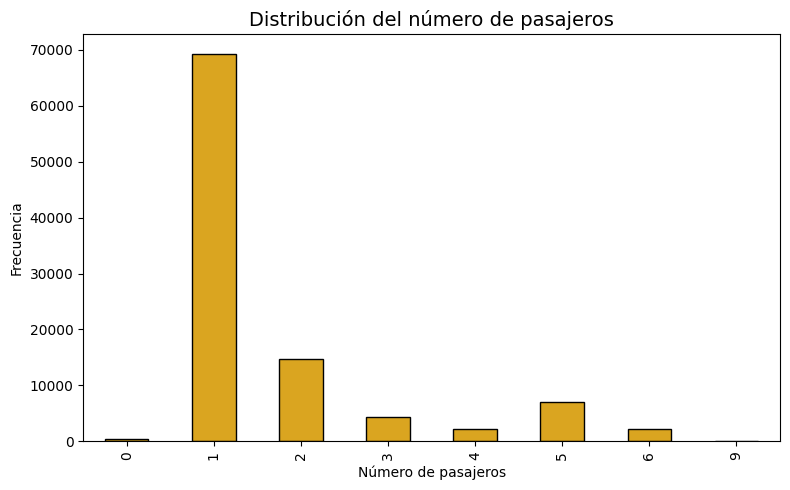

In [49]:
fig, ax = plt.subplots(figsize=(8, 5))
df['passenger_count'].value_counts().sort_index().plot(kind='bar', ax=ax, color='goldenrod', edgecolor='black')
ax.set_title('Distribución del número de pasajeros', fontsize=14)
ax.set_xlabel('Número de pasajeros')
ax.set_ylabel('Frecuencia')
plt.tight_layout()
plt.show()


Al igual que en el caso anterior aquí se ve reflejado un conjunto de outliers o valores irracionales que deben ser tratados en el dataset. En concreto, viajes con 0 pasajeros no son realistas o viajes con 9 pasajeros son extremadamente raros (confirmando así mi sospecha inicial). Como se explica posteriormente, estas filas se eliminarán del set de entrenamiento para no influir negativamente en las predicciones del modelo.

#### 3.9 Relación entre distancia y coste
Se analiza la correlación entre la distancia del trayecto y el coste.

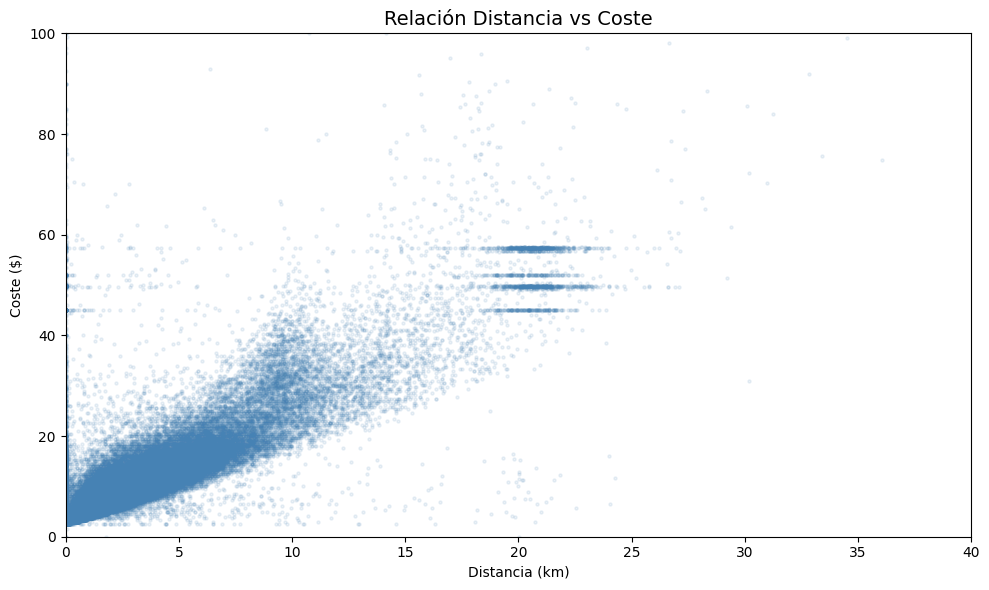

Correlación distancia-coste: 0.0282


In [50]:
fig, ax = plt.subplots(figsize=(10, 6))
ax.scatter(df['trip_distance_km'], df['fare_amount'], alpha=0.1, s=5, color='steelblue')
ax.set_title('Relación Distancia vs Coste', fontsize=14)
ax.set_xlabel('Distancia (km)')
ax.set_ylabel('Coste ($)')
ax.set_xlim(0, 40)
ax.set_ylim(0, 100)
plt.tight_layout()
plt.show()

print(f'Correlación distancia-coste: {df["trip_distance_km"].corr(df["fare_amount"]):.4f}')


Esta gráfica es muy interesante ya que muestra como no existe linealidad estrictamente hablando en la relación distancia-coste. Bien es cierto que visualmente el coste crece poco a poco a medida que aumenta la distancia pero no puede considerarse lineal al ser representado como una nube de puntos tan densa en vez de una recta clara fina con precios muy marcados por la distancia. Además, la correlación de **distancia-coste** con valor 0.0282 corrobora la conclusión de que la relación lineal es débil, por lo que por sí sola esta característica no da gran información a no ser que se añadan otras características del dataset. Además de esto se puede ver como para ciertas franjas de distancias entre 17-23km hay líneas horizontales más marcadas que pueden sugerir precios fijos por tarifas de viajes de ciertas distancias. Además, hay muchas dispersión de valores, para viajes de 5km se concentra la mayor cantidad de viajes en precios entre 0-20$ pero hay casos de más de 40$ (influyen factores de hora del día o tipo de vehículo por ejemplo).

#### 3.10 Coordenadas inválidas

A continuación se hace un análisis de la cantidad de datos de longitud y latitud iincorrectas para comprobar como han afectado a las estadísticas comentadas al principio de la sección.

Como se comentaba en el **Apartado 3.1** la franja de valores posibles para estas magnitudes son:
- Latitud: de -90° a +90° (polo sur a polo norte)
- Longitud: de -180° a +180° (meridiano de Greenwich como referencia)

Cualquier valor fuera de esas franjas es un valor ficticio o incorrecto

In [51]:
# Conteo de registros con coordenadas físicamente imposibles
inv_pickup_lon  = df[(df['pickup_longitude'] < -180) | (df['pickup_longitude'] > 180)]
inv_pickup_lat  = df[(df['pickup_latitude']  < -90)  | (df['pickup_latitude']  > 90)]
inv_dropoff_lon = df[(df['dropoff_longitude'] < -180) | (df['dropoff_longitude'] > 180)]
inv_dropoff_lat = df[(df['dropoff_latitude']  < -90)  | (df['dropoff_latitude']  > 90)]

print('Registros con coordenadas físicamente imposibles:')
print(f'  pickup_longitude  fuera de [-180, 180]: {len(inv_pickup_lon)}')
print(f'  pickup_latitude   fuera de [-90,  90]:  {len(inv_pickup_lat)}')
print(f'  dropoff_longitude fuera de [-180, 180]: {len(inv_dropoff_lon)}')
print(f'  dropoff_latitude  fuera de [-90,  90]:  {len(inv_dropoff_lat)}')

Registros con coordenadas físicamente imposibles:
  pickup_longitude  fuera de [-180, 180]: 4
  pickup_latitude   fuera de [-90,  90]:  0
  dropoff_longitude fuera de [-180, 180]: 1
  dropoff_latitude  fuera de [-90,  90]:  1


Esta es la casuística más interesante ya que se había visto en el **Apartado 3.1** que aparecen coordenadas en el dataset que no son realistas dado que el valor de latitud o longitud supera la franja de valores que pueden adoptar estas magnitudes. Como se ve, hay 6 casuísticas de coordenadas de latitud o longitud incorrectas y deben ser tratadas para crear un modelo fiable.

#### 3.11 Matriz de correlación


Por último, se ha decidido representar las correlaciones entre las distintas variables del dataset en busca de relaciones interesantes que puedan ayudar en el posterior tratamiento de datos para el modelo.

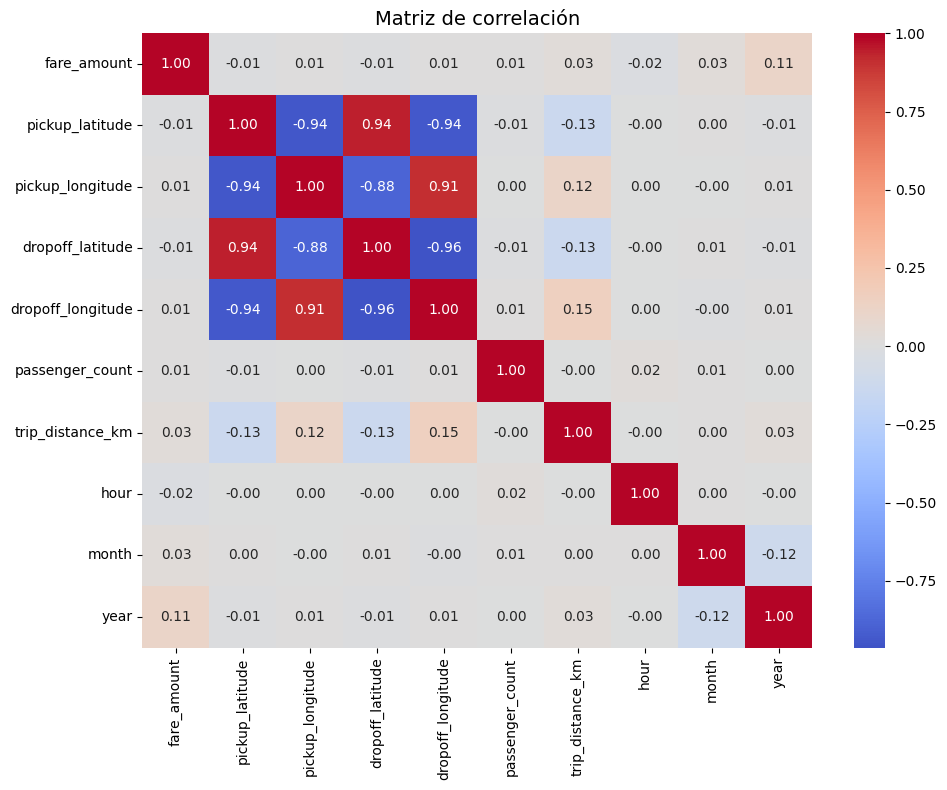

In [52]:
fig, ax = plt.subplots(figsize=(10, 8))
numeric_cols = ['fare_amount', 'pickup_latitude', 'pickup_longitude', 
                'dropoff_latitude', 'dropoff_longitude', 'passenger_count', 
                'trip_distance_km', 'hour', 'month', 'year']
corr_matrix = df[numeric_cols].corr()
sns.heatmap(corr_matrix, annot=True, fmt='.2f', cmap='coolwarm', ax=ax, center=0)
ax.set_title('Matriz de correlación', fontsize=14)
plt.tight_layout()
plt.show()


Como se ve en la matriz de correlación, existen correlaciones fuertes entre las distintas latitudes y longitudes lo cuál era previsible. Por otro lado no hay ninguna otra correlación fuerte que merezca la pena comentar. Es interesante remarcar que ninguna variable tiene una correlación fuerte con la variable objetivo a predecir por el modelo **fare_amount**. Esto indica que el modelo requiere de todas las variables posibles para hacerse una idea más acertada del coste de los viajes que tendrá que predecir. 

#### 3.12 Conclusiones del EDA

Tras el análisis completo del EDA se han podido obtener varias conclusiones sobre la naturaleza de los datos que deben tenerse en cuenta para el posterior tratamiento de los datos sobre el set de entrenamiento. Los más importantes son:

- Hay datos de las longitudes y latitudes que no existen en el mundo real. 
- Hay viajes con 0 o 9 pasajeros que se van a considerar valores incorrectos o atípicos. 
- Hay valores atípicos importantes a considerar tanto para la columna de costes como la columna de distancias.
- No existe una correlación clara entre ninguna de las variables con la variable objetivo. La variable con mayor correlación con la variable objetivo es **year** y el valor de la correlación no es lo suficientemente alto como para considerarlo determinante.
- No existe una distribución ni correlación clara entre la cantidad de viajes y los años, meses o días de la semana. Aún así si que existe una relción entre la cantidad de viajes por hora del día.
- La relación entre distancia y coste, la cuál se esperaba que fuera lineal, no lo es, sino que por el contrario tiene una relación lineal muy débil (correlación de **0.028**) con una nube de puntos densa para los valores inferiores y que se va dispersando a medida que aumenta la distancia. Aún así, si que se puede ver como la nube de puntos tiende a ascender al aumentar la distancia siguiendo un mínimo de linealidad. Además las tarifas fijas de precios que se comentaban entre los 17-23km también hacen que la linealidad empeore.


Por lo tanto, se seguirá con el resto del cuaderno, y en el apartado de creación del modelo (**Paso 5**) se aplicarán las transformaciones pertinentes sobre el set de entrenamiento para mejorar el rendimiento del modelo.

### Paso 4: Datos de localización

A continuación vamos a realizar un análisis de los datos de localización. Para simplificar este análisis vamos a coger los 200 primeros registros del dataset:  


In [53]:
location_sample = df[['pickup_latitude', 'pickup_longitude']].head(200).copy()
location_sample_list = location_sample.values.tolist()

Una vez preparado el dataset para esta parte, vamos a empezar a representar los datos en mapas.
Como base utilizaremos la librería [Folium](https://python-visualization.github.io/folium/) para la representación de los mapas.

#### Ejemplo mapa

El primer mapa que vamos a realizar va a ser un mapa con los marcadores de todos los puntos sobre el.
Para ello, creamos un mapa localizaco en NYC y después con *`folium.Marker`* vamos añadiendo los marcadores al mapa


In [54]:
map = folium.Map(location=[40.730610, -73.935242], zoom_start=12)
for point in range(0, len(location_sample_list)):
    folium.Marker(location_sample_list[point], popup=df['trip_distance_km'][point]).add_to(map)
map

#### Autocompletar

A continuación, se espera que el alumno repita el mismo ejercicio, pero esta vez creando un grupo de marcadores (cluster). Para ello hay que utilizar además del código anterior, la función `MarkerCluster()` y añadirlo al mapa.

Para este apartado se ha utilizado el **MarkerCluster()** comentado en las instrucciones del apartado. La lógica es parecida la que se da de ejemplo en la celda anterior pero añadiendo los marcaddores de clusters para organizar todos los marcados en grupos y dejar mucho más limpio el mapa. 

El MarkerCluster agrupa automáticamente los marcadores cercanos, mostrando el número de puntos en cada grupo. 
Al hacer zoom o clickar en uno de los clusters, estos se desagregan revelando los marcadores individuales o clusters más pequeños. Esto es muy útil cuando hay muchos puntos para evitar la saturación visual del mapa. Además se ha considerado interesante cambiar el formato del popup para que al pinchar sobre el marcador, la información sea más interesante que únicamente mostrar un número como en el ejemplo.

In [55]:
# Mapa con MarkerCluster
map_cluster = folium.Map(location=[40.730610, -73.935242], zoom_start=12)

# Crear el grupo de marcadores (cluster)
marker_cluster = MarkerCluster().add_to(map_cluster)

# Añadir los marcadores al cluster en lugar de directamente al mapa
for point in range(0, len(location_sample_list)):
    folium.Marker(
        location_sample_list[point], 
        popup=f'Distancia: {df["trip_distance_km"].iloc[point]:.2f} km'
    ).add_to(marker_cluster)

map_cluster


Como se puede observar se ha conseguido una buena organización en clusters y ahora los popups de los marcadores tienen una información más intuitiva. Además es muy interesante observar al volver el mapa mucho más pequeño y poder verlo a nivel mundial como aparecen en una zona irracional del mapa 6 puntos (coincidiendo con los 6 puntos localizados con magintdes de longitud y latitud incorrectas).

#### Trabajo con celdas h3

El siguiente análisis se va a hacer utilizando un algoritmo de hashing para las localizaciones, en concreto utilizaremos [H3](https://h3geo.org/) un sistema de indexación geoespacial jerárquico hexagonal.

Para ello, vamos a utilizar la librería de Python `h3pandas` (instalada en el paso 1). Esta librearía nos permite convertir puntos de latitud y longitud a la celda h3 correspondiente, con la resolución indicada y trabajar con este tipo de localizaciones. Más información en la documentación oficial: [h3pandas](https://github.com/DahnJ/H3-Pandas).


A continuación se adjunta una tabla con las resoluciones de h3:

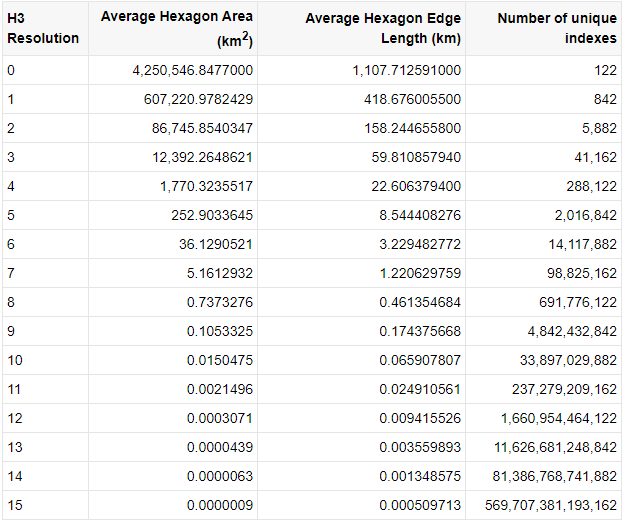



In [56]:
## Código para convertir pickup_latitude y pickup_longitude a un h3 de nivel 8. Creación de dicha columna en el dataframe
resolution = 8
df = df.h3.geo_to_h3(resolution,lat_col='pickup_latitude', lng_col='pickup_longitude')
df.head()

,key,fare_amount,pickup_datetime,pickup_longitude,pickup_latitude,dropoff_longitude,dropoff_latitude,passenger_count,trip_distance_km,year,month,day_of_week,hour,day_name
h3_08,,,,,,,,,,,,,,
882a10725bfffff,2011-05-31 22:21:01.0000004,7.3,2011-05-31 22:21:01+00:00,-73.994009,40.761440,-73.972811,40.792574,1,3.895004,2011,5,1,22,Martes
882a100883fffff,2011-05-11 13:26:00.0000007,14.1,2011-05-11 13:26:00+00:00,-73.976888,40.787700,-73.967403,40.761462,2,3.024882,2011,5,2,13,Miércoles
882a1072c1fffff,2015-02-12 16:37:31.0000002,6.0,2015-02-12 16:37:31+00:00,-74.003326,40.720531,-74.008217,40.716930,1,0.574636,2015,2,3,16,Jueves
882a1072c1fffff,2012-03-28 21:05:00.000000196,19.3,2012-03-28 21:05:00+00:00,-73.999330,40.722333,-73.935865,40.684185,1,6.827491,2012,3,2,21,Miércoles
882a100d6bfffff,2010-08-07 06:07:30.0000002,8.1,2010-08-07 06:07:30+00:00,-73.965385,40.761611,-73.991350,40.749571,1,2.564272,2010,8,5,6,Sábado


In [57]:
## Código para agregar por h3 de nivel 8 y suma de las repeticiones
resolution = 8
location_sample["count"] = 1
df_grouped=location_sample.h3.geo_to_h3_aggregate(resolution,lat_col='pickup_latitude', lng_col='pickup_longitude')

Una vez creada la columna con el h3 correspondiente, se espera que el alumno represente dichos h3 en el mapa. La representación en el mapa debe ser de los h3 y el número de repeticiones de h3 que hay en el dataset (de las 200 muestras). Se adjunta captura de ejemplo del resultado esperado:

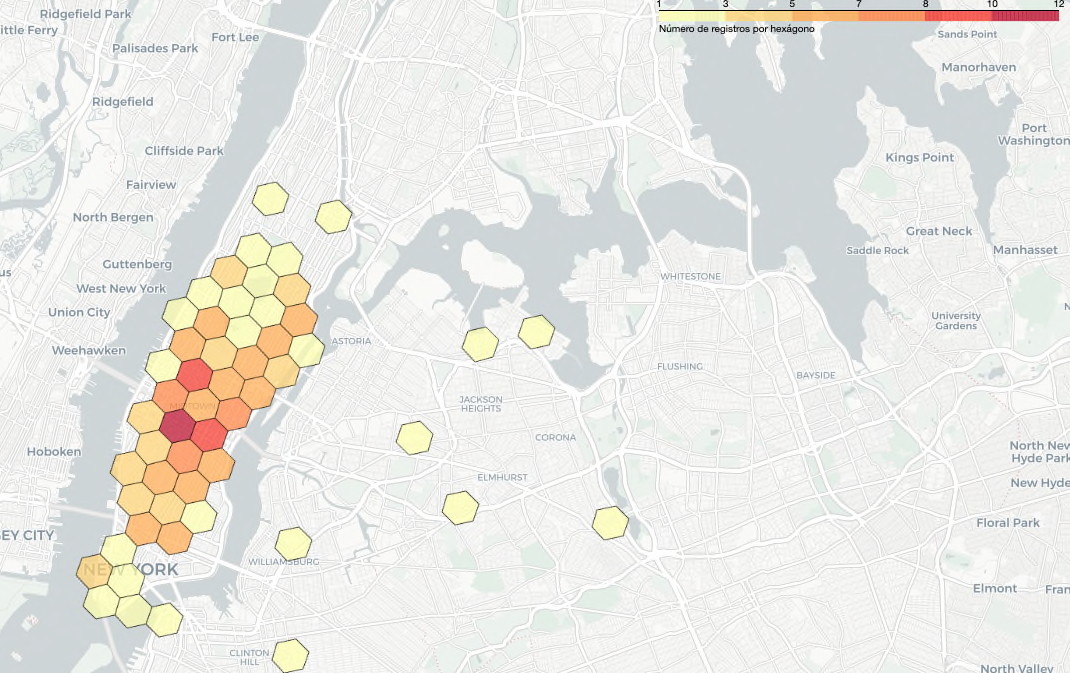

PISTA: Se puede utilizar la función `Choropleth()` de folium.

BONUS TRACK!! Encuentra la forma de añadir un popup sobre los h3 en el mapa, para indicar el número de repeticiones.

Se ha utilizado **.explore()** de GeoPandas en lugar de **Choropleth()** de Folium, ya que una vez que **h3_to_geo_boundary()** devuelve un GeoDataFrame, **.explore()** permite visualizarlo de forma interactiva de manera más directa, facilitando mucho más su implementación que **Chroropleth()** que debe tenerse más en cuenta su configuración.

Por otro lado para el Bonus Track se ha utilizado el argumento **popup** que al especificarle **['count']** se muestra en un popup el número de repeticiones al clickar sobre el hexágono. Además, al pasar el ratón por encima del hexágono también se muestra el número de repeticiones gracias al parámetro **tooltip** con valor igual a **['count']**.

In [58]:
map_h3 = folium.Map(location=[40.730610, -73.935242], zoom_start=12)

df_grouped.h3.h3_to_geo_boundary().explore(
    column='count',
    cmap='YlOrRd',
    tooltip=['count'],      # info al pasar el ratón
    popup=['count'],        # popup al hacer click
    legend=True,
    style_kwds={'fillOpacity': 0.6, 'weight': 1},
    m=map_h3
)

map_h3

**Observación:** Los hexágonos H3 permiten discretizar el espacio geográfico de forma uniforme. 
Los colores más cálidos (rojo/naranja) indican zonas con mayor densidad de recogidas de taxi. 

Como se puede observar se ha logrado obtener exactamente la distribución de hexágonos que se daba en el ejemplo. Además, se ha conseguido obtener el popup con el número de repeticiones que se pedía como extra. Para hacerlo más completo no solo hay un popup sino que si se pasa el ratón por encima del marcador también se mostrará el número de repeticiones. Ante esta representación se puede ver como la mayor cantidad de viajes se concentra en Manhattan u alrededores, percibiendo pocos viajes fuera de esa zona. 

Otro resultado interesante es la poca cantidad de viajes que hay hacia el aeropuerto, ya que en un principio se podría haber estimado que sería un sitio con alta frecuencia de viajes. Aún así, dado que solo se ha hecho la representación de 200 muestras, esto puede no llegar a ser representativos del dataset completo. 

### Paso 5: Modelo predicción de coste de ruta

El siguiente paso es construir un modelo que haga la predicción del coste en base a la distancia del trayecto y la hora del día y cualquier otra información útil en el dataset proporciando.

Crete tu propio modelo de machine learning y haz las transformaciones necesarias para tu modelo a continuación.

#### Autocompletar

#### 5.1 Preparación de datos para el modelo

Se preparan las features para el modelo de predicción de coste. Se usa:
- `trip_distance_km`: distancia del trayecto
- `hour`: hora del día
- `day_of_week`: día de la semana
- `month`: mes
- `passenger_count`: número de pasajeros
- Coordenadas de pickup y dropoff

Además se divide ya el dataset en el conjunto de entrenamiento y el de evaluación

In [59]:
# División train/test
df_train, df_test = train_test_split(df, test_size=0.2, random_state=42)

features = ['trip_distance_km', 'hour', 'day_of_week', 'month', 'passenger_count',
            'pickup_latitude', 'pickup_longitude', 'dropoff_latitude', 'dropoff_longitude']
target = 'fare_amount'

#### 5.2 Limpieza de datos

Dado que la limpieza de datos se suele hacer únicamente para el set de entrenamiento se ha esperado a este punto de la práctica dónde se acaban de dividir los datos para limpiar los outliers únicamente en el set de entrenamiento.

En el análisis descriptivo inciial se han identificado valores erróneos, ficticios o atípicos en el dataset. Como se ha visto que no hay valores NaN simplemente hay que tratar los valores atípicos que se han encontrado. Además, en clase la profesora sugirió no entrar en gran profundidad en el EDA y el tratamiento de los datos dado que el objetivo final de la práctica está más orientado a la creación del modelo y al aprendizaje de las distintas formas de representar el mapa y sus variaciones, por lo que se optará por la opción más sencilla que es eliminar las filas con los datos atípicos ya que son tan pocas que no influye en el entrenamiento del modelo deshacerse de ellas directamente.

- **Latitudes y longitudes incorrectas**: Dado que no se conoce la razón real por la que están presentes estas magnitudes incorrectas, es preferible no asumir la razón para no engañar al modelo cuando se entrene. Por eso he decidido que la mejor opción es eliminar las filas influidas por estos valores atípicos.

- **0 o 9 Pasajeros**: Dado que la cantidad de pasajeros no suele ser menor a 1 ni mayor a 6 se ha decidido que cualquier fila con valores inferiores a 1 o superiores a 6 también sea eliminada.

- **Valores atípicos en distancias y costes**: Para las distancias y costes elevados se han puesto límites superiores e inferiores razonables teniendo en cuenta lo siguiente (resultados del EDA):
    - Distancias: Mediana de 2.12km y media de 19.44km. Se le asigna un valor máximo de 100km y mínimo mayor que 0km.
    - Costes: Mediana de 8.5$ y media alrededor de 11.3$. Se asume un máximo de 100$ y mínimo mayor que 0$.

Cabe destacar que si el objetivo de la práctica hubiera sido la elaboración del EDA y la transformación de datos se podrían haber estudiado otro tipo de transformaciones como estandarización y normalización de datos, al igual que haber buscado otro modo de gestionar outliers o valores ficticios. Dado que se nos sugirió no hacer un análisis descriptivo ni unas transformaciones tan detalladas se ha preferido simplificar este paso para focalizar y profundizar más en el resto de apartados del laboratorio.

In [60]:
print(f'Filas antes de limpieza: {len(df_train)}')

df_train = df_train[
    (df_train['pickup_latitude'].between(-90, 90)) &
    (df_train['dropoff_latitude'].between(-90, 90)) &
    (df_train['pickup_longitude'].between(-180, 180)) &
    (df_train['dropoff_longitude'].between(-180, 180))
]
df_train = df_train[(df_train['passenger_count'] >= 1) & (df_train['passenger_count'] <= 6)]
df_train = df_train[(df_train['trip_distance_km'] > 0) & (df_train['trip_distance_km'] <= 100)]
df_train = df_train[(df_train['fare_amount'] > 0) & (df_train['fare_amount'] <= 100)]

print(f'Filas después de limpieza: {len(df_train)}')
print(f'Filas eliminadas: {100000 - len(df_train)}')

Filas antes de limpieza: 79998
Filas después de limpieza: 77251
Filas eliminadas: 22749


Se dividen las features y el target tanto para el train set como para el test set

In [61]:

X_train = df_train[features].copy()
y_train = df_train[target].copy()

X_test = df_test[features].copy()
y_test = df_test[target].copy()

#### 5.3 Preparación de modelos
Dado que no se quiere limitar las posibilidades del mejor modelo, he decidido probar distintos modelos típicos para problemas de regresión. Se han decidido explorar distintas alternativas basados en distintos fundamentos como modelos lineales o modelos basados en árboles de decisión. Estos últimos son los más interesantes a utilizar seguramente en este caso práctico dado que son robustos ante valores atípicos y tienen buen rendimiento en problemas de regresión al no estar afectados por datos sin escalar. Es por ello que se prueban distintos modelos basados en árboles de decisiones, unos más simples y otros más avanzados.

Dado que solo interesa hacerse una idea inicial de cuál puede ser el mejor, se fijan ciertos hiperparámetros para cada modelo que hacen que el rendimiento sea óptimo para un análisis inicial. Tras esto se elige el mejor modelo obtenido y se ajustan los hiperparámetros del mismo para obtener el mejor modelo posible.

In [62]:
models = {
    'Linear Regression':  LinearRegression(),
    'Ridge Regression':   Ridge(alpha=1.0),
    'Decision Tree':      DecisionTreeRegressor(max_depth=5, random_state=42),
    'Random Forest':      RandomForestRegressor(n_estimators=100, max_depth=5, random_state=42),
    'Gradient Boosting':  GradientBoostingRegressor(n_estimators=100, max_depth=5, learning_rate=0.1, random_state=42),
    'XGBoost':            XGBRegressor(n_estimators=100, max_depth=5, learning_rate=0.1, random_state=42, verbosity=0),
    'LightGBM':           LGBMRegressor(n_estimators=100, max_depth=5, learning_rate=0.1, random_state=42, verbose=-1),
}

for name, model in models.items():
    print(f'Entrenando {name}...')
    model.fit(X_train, y_train)

Entrenando Linear Regression...
Entrenando Ridge Regression...
Entrenando Decision Tree...
Entrenando Random Forest...
Entrenando Gradient Boosting...
Entrenando XGBoost...
Entrenando LightGBM...


#### 5.4 Evaluación del modelos


Los modelos se evaluan tanto para las predicciones con el modelo de entrenamiento como en el de evaluación. Aún así, se da más importancia a los resultados obtenidos con las predicciones del set de evaluación. Además en caso de no tener claro que modelo es mejor (en caso de que un modelo supere a otro en MAE pero sea peor en RMSE por ejemplo) se tomará el modelo con mejor MAE.

In [63]:
results = []

for name, model in models.items():
    y_pred_train = model.predict(X_train)
    y_pred_test  = model.predict(X_test)

    results.append({
        'Modelo':      name,
        'MAE Train':   mean_absolute_error(y_train, y_pred_train),
        'MAE Test':    mean_absolute_error(y_test,  y_pred_test),
        'RMSE Train':  np.sqrt(mean_squared_error(y_train, y_pred_train)),
        'RMSE Test':   np.sqrt(mean_squared_error(y_test,  y_pred_test)),
        'R² Train':    r2_score(y_train, y_pred_train),
        'R² Test':     r2_score(y_test,  y_pred_test),
    })

results_df = pd.DataFrame(results).sort_values('MAE Test')
print('Comparación de modelos')
print(results_df.to_string(index=False))

best_name = results_df.iloc[0]['Modelo']
best_model = models[best_name]
print(f'\nMejor modelo: {best_name}')

Comparación de modelos
           Modelo  MAE Train  MAE Test  RMSE Train  RMSE Test  R² Train      R² Test
          XGBoost   1.946823  2.409482    3.420384   5.300230  0.867165     0.702417
         LightGBM   1.978626  2.443698    3.541579   5.310192  0.857585     0.701298
Gradient Boosting   1.935837  2.498253    3.283830   5.528798  0.877560     0.676198
    Decision Tree   2.255633  2.666142    3.986455   5.339664  0.819559     0.697973
    Random Forest   2.200511  2.669530    3.884793   5.376423  0.828644     0.693800
Linear Regression   2.369528 24.129295    4.763113 618.575119  0.742401 -4052.245928
 Ridge Regression   2.369561 24.132146    4.763116 618.645157  0.742401 -4053.163839

Mejor modelo: XGBoost


Tras el entrenamiento y la evaluación se puede ver que el mejor modelo es XGBoost, siendo el modelo más estable y que se comporta mejor para cualquiera de las métricas en el dataset de evaluación (el cuál es el más importante). Aún así, se ven modelos que rivalizan con este, como pueden ser LightGBM o Gradient Boosting. Por otro lado cabe destacar como modelos como Linear Regression o Ridge Regression tienen resultados de las métricas de evaluación muy malos. Esto ya se comentaba durante el EDA al comparar coste respecto a distancia, donde se mencionaba que no seguía la nube de puntos una distribución lineal fuerte sino más bien débil (correlación de 0.028).

Por lo tanto, se reafirma que los resultados no siguen distribuciones lineales que ayuden a regresores lineales a predecir y se ha comprobado que la teoría sobre el gran rendimiento de modelos basados en árboles de decisión presentada al inicio de la sección era correcta ya que estos modelos han sido los que mejores resultados han tenido.

Tras esto se procede con la optimización de hiperparámetros para el modelo elegido, XGBoost.

#### 5.5 Optimización del modelo elegido

Se han elegido hiperparámetros típicos para el ajuste de hiperparámetros y obtener el mejor modelo psoible.

In [64]:
param_grid = {
    'n_estimators':        [100, 200, 300],
    'max_depth':           [3, 4, 5, 6, 8],
    'learning_rate':       [0.01, 0.05, 0.1],
    'reg_alpha':           [0, 0.01, 0.1],   # L1
    'reg_lambda':          [0.1, 1.0, 2.0], # L2
}

random_search = RandomizedSearchCV(
    estimator=XGBRegressor(random_state=42, verbosity=0),
    param_distributions=param_grid,
    n_iter=80,
    scoring='neg_mean_absolute_error',
    cv=5,
    n_jobs=-1,
    verbose=2,
    random_state=42
)

print('Iniciando búsqueda de hiperparámetros para XGBoost...')
random_search.fit(X_train, y_train)

print(f'\nMejores hiperparámetros: {random_search.best_params_}')
print(f'MAE CV: ${-random_search.best_score_:.2f}')

Iniciando búsqueda de hiperparámetros para XGBoost...
Fitting 5 folds for each of 80 candidates, totalling 400 fits
[CV] END learning_rate=0.01, max_depth=5, n_estimators=200, reg_alpha=0.1, reg_lambda=1.0; total time=   1.4s
[CV] END learning_rate=0.01, max_depth=5, n_estimators=200, reg_alpha=0.1, reg_lambda=1.0; total time=   1.4s
[CV] END learning_rate=0.01, max_depth=5, n_estimators=200, reg_alpha=0.1, reg_lambda=1.0; total time=   1.8s
[CV] END learning_rate=0.05, max_depth=6, n_estimators=100, reg_alpha=0, reg_lambda=2.0; total time=   1.5s
[CV] END learning_rate=0.05, max_depth=6, n_estimators=100, reg_alpha=0, reg_lambda=2.0; total time=   1.7s
[CV] END learning_rate=0.01, max_depth=4, n_estimators=100, reg_alpha=0.1, reg_lambda=0.1; total time=   0.6s
[CV] END learning_rate=0.05, max_depth=6, n_estimators=100, reg_alpha=0, reg_lambda=2.0; total time=   2.0s
[CV] END learning_rate=0.05, max_depth=6, n_estimators=100, reg_alpha=0, reg_lambda=2.0; total time=   2.2s
[CV] END lea

#### 5.6 Evaluación del modelo optimizado

In [65]:
best_xgb = random_search.best_estimator_

y_pred_train = best_xgb.predict(X_train)
y_pred_test  = best_xgb.predict(X_test)

print('XGBoost optimizado')
print(f'{"":20} {"TRAIN":>10} {"TEST":>10}')
print(f'{"MAE":20} ${mean_absolute_error(y_train, y_pred_train):>9.2f} ${mean_absolute_error(y_test, y_pred_test):>9.2f}')

# Comparación con el XGBoost base
base_xgb = models['XGBoost']
y_pred_base = base_xgb.predict(X_test)
print(f'\nComparación vs XGBoost base')
print(f'MAE base:      ${mean_absolute_error(y_test, y_pred_base):.2f}')
print(f'MAE optimizado: ${mean_absolute_error(y_test, y_pred_test):.2f}')
print(f'Mejora:         ${mean_absolute_error(y_test, y_pred_base) - mean_absolute_error(y_test, y_pred_test):.2f}')

XGBoost optimizado
                          TRAIN       TEST
MAE                  $     1.35 $     2.39

Comparación vs XGBoost base
MAE base:      $2.41
MAE optimizado: $2.39
Mejora:         $0.02


Como se puede ver la mejora para el MAE no ha sido significativa incluso después del ajuste de hiperparámetros. Aún así, se puede sacar en claro que si se siguiera intentando optimizar el modelo podría sufrir de **overfitting** dado que se ve reflejado en los resultados que el modelo predice mucho mejor en el set de entrenamiento que en el de evaluación.

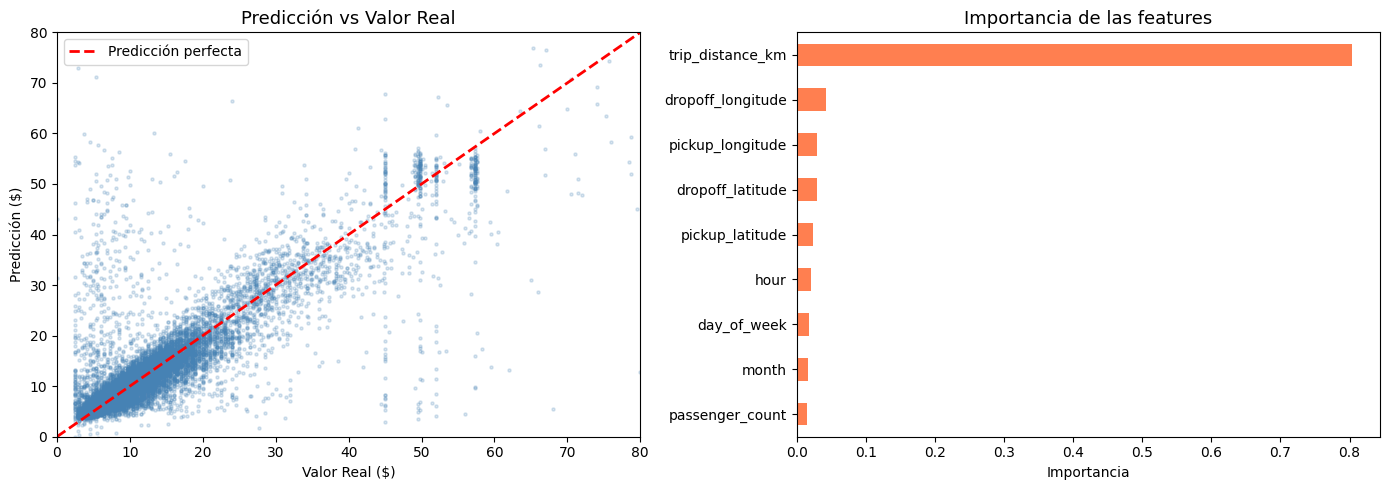

In [66]:
model = best_xgb
# Visualización: Predicción vs Real
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Scatter plot
axes[0].scatter(y_test, y_pred_test, alpha=0.2, s=5, color='steelblue')
axes[0].plot([0, 100], [0, 100], 'r--', lw=2, label='Predicción perfecta')
axes[0].set_title('Predicción vs Valor Real', fontsize=13)
axes[0].set_xlabel('Valor Real ($)')
axes[0].set_ylabel('Predicción ($)')
axes[0].set_xlim(0, 80)
axes[0].set_ylim(0, 80)
axes[0].legend()

# Feature importance
importance = pd.Series(model.feature_importances_, index=features)
importance.sort_values().plot(kind='barh', ax=axes[1], color='coral')
axes[1].set_title('Importancia de las features', fontsize=13)
axes[1].set_xlabel('Importancia')

plt.tight_layout()
plt.show()


#### 5.7 Conclusiones del modelo elegido
El modelo finalmente elegido ha sido un modelo de XGBoost. Este modelo a priori era mi favorito a usar dado que es un modelo avanzado basado en árboles de decisión que funciona muy bien en problemas de regresión como este dada su robustez ante valores atípicos o valores nulos.

Como se puede ver en los resultados, la optimización de hiperparámetros ha sido útil aunque no ha sido diferencial, ya que mejora levemente los resultados obtenidos con los parámetros iniciales. Además, se observa que comparado con los resultados anteriores a la optimización, mejora bastante en el conjunto de entrenamiento pero no sobre el conjunto de test, por lo que buscar un ajuste más exhaustivo podría provocar overfitting.

Por último, las gráficas muestran datos interesantes.

Para la gráfica de la izquierda se puede ver que la nube de puntos sigue razonablemente bien la línea roja de predicción perfecta, esto nos indica que el modelo ha tenido un buen rendimiento en la predicción. 

Aún así dejo por aquí una imagen obtenida del EDA anterior sobre la relación entre distancia y coste del dataset:

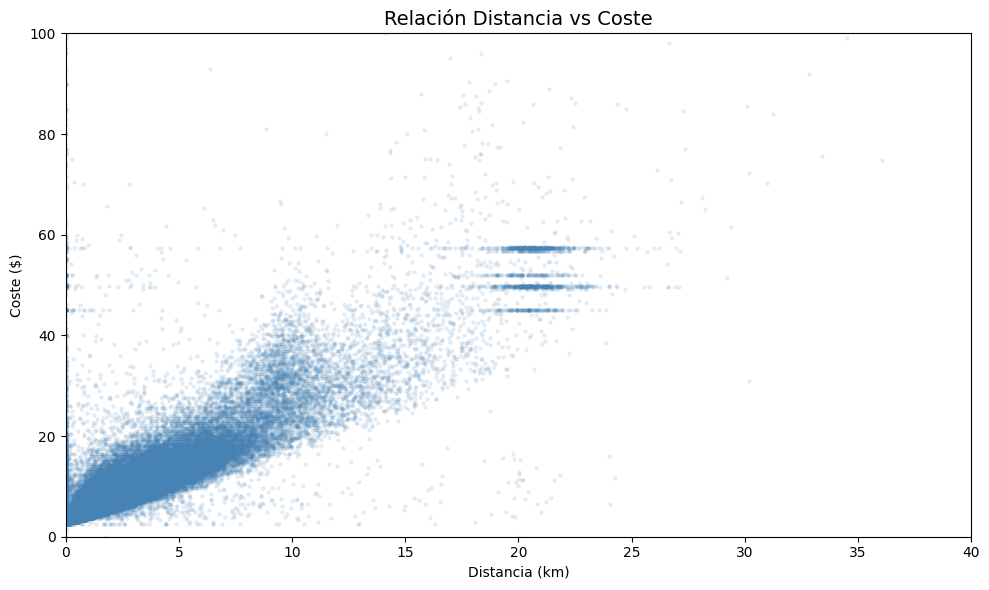

En esa imagen comentaba antes que había un patrón de precio lineal en torno a los viajes de 20km de distancia donde el precio seguía una linealidad entre 40 y 60 euros (generando así las 3 líneas horizontales marcadas que se ven). En la grafica de predicciones del modelo se identifican estas líneas de forma vertical entre 40-60$ del valor real (eje X). Esto probablemente sea porque el modelo no ha sido capaz de capturar esta característica de tarifa fija por distancia haciendo así que se formen esas líneas totalmente verticales características (mientras que el precio real se mantiene firme entorno a unos valores, el precio predicho varía generando las líneas verticales).

Por otro lado la imagen de la derecha es intersante ya que deja en evidencia el hecho de que la distancia del viaje es sin dudas la característica de mayor importancia y en la que más se apoya en el modelo.

### Paso 6: Predicción de coste de rutas desde un punto dado

Una vez creado el modelo, se debe coger como punto de partida unas coordenadas fijas dentro del h3 que más viajes ha tenido en el dataset dado, que sería el punto de pickup, y se obtenga la predicción del coste de ir a **5 destinos turísticos en Nueva York**, que serían los puntos de dropoff. Por ejemplo: (lat, long):
- Times Square  (40.758, -73.985)
- Empire State   (40.748, -73.985)
- Central Park    (40.782, -73.966)

Busca tus desstinos!

#### Autocompletar

Generar los nuevos datos y precedir el coste a continuación:



#### 6.1 Preparación de datos

Dado que son datos sintéticos he tenido que crear una función capaz de calcular la distancia haversine para obtener la distania que se lleva utilizando durante toda la práctica en el dataset.

In [67]:
# Definir función haversine para calcular distancias para la creación de datos sintéticos
def haversine(lat1, lon1, lat2, lon2):
    R = 6371
    lat1 = np.radians(lat1)
    lon1 = np.radians(lon1)
    lat2 = np.radians(lat2)
    lon2 = np.radians(lon2)
    dlat = lat2 - lat1
    dlon = lon2 - lon1
    a = np.sin(dlat/2)**2 + np.cos(lat1) * np.cos(lat2) * np.sin(dlon/2)**2
    return R * 2 * np.arctan2(np.sqrt(a), np.sqrt(1-a))

Se establece el h3 con más viajes como punto de pickup basándome en el dataframe completo.

In [68]:
# Encontrar el H3 con más viajes (punto de pickup)
h3_counts = df.index.value_counts()
most_common_h3 = h3_counts.index[0]
print(f'H3 con más viajes: {most_common_h3}')
print(f'Número de viajes desde este H3: {h3_counts.iloc[0]}')

pickup_lat, pickup_lng = h3.cell_to_latlng(most_common_h3)
print(f'Coordenadas del pickup (centro del H3): ({pickup_lat:.6f}, {pickup_lng:.6f})')


H3 con más viajes: 882a100d2dfffff
Número de viajes desde este H3: 4839
Coordenadas del pickup (centro del H3): (40.749808, -73.990004)


#### 6.2 Predicción de destinos elegidos

Se han buscado los sitios turísticos más interesantes. En un primer momento sin caer en la cuenta de que estaba en una pequeña isla puse la Estatua de la Libertad a la cuál no se puede llegar en taxi. Como me pareció interesante lo he dejado como sexto punto extra aunque realmente no se pueda llegar allí solo con un taxi. El resto de puntos elegidos son lugares populares de Nueva York.

En concreto los destinos elegidos son:

- Times Square: (40.758, -73.985),
- Empire State Building: (40.748, -73.985),
- Central Park: (40.782, -73.966),
- Grand Central Terminal: (40.753, -73.977),
- Brooklyn Bridge: (40.706, -73.997),
- Estatua de la Libertad [Extra]: (40.689, -74.045)

In [69]:
# Definir 5 destinos turísticos en Nueva York (viables para llegar) + Estatua de la Libertad
destinos = {
    'Times Square': (40.758, -73.985),
    'Empire State Building': (40.748, -73.985),
    'Central Park': (40.782, -73.966),
    'Grand Central Terminal': (40.753, -73.977),
    'Brooklyn Bridge': (40.706, -73.997),
    'Estatua de la Libertad [Extra]': (40.689, -74.045)
}

# Generar datos para predicción
predicciones = []

for nombre, (dest_lat, dest_lng) in destinos.items():
    # Calcular distancia haversine
    dist = haversine(pickup_lat, pickup_lng, dest_lat, dest_lng)
    
    # Crear feature vector (simular viaje a las 14:00, miércoles, junio, 1 pasajero)
    features_pred = pd.DataFrame({
        'trip_distance_km': [dist],
        'hour': [14],
        'day_of_week': [2],  # Miércoles
        'month': [6],  # Junio
        'passenger_count': [1],
        'pickup_latitude': [pickup_lat],
        'pickup_longitude': [pickup_lng],
        'dropoff_latitude': [dest_lat],
        'dropoff_longitude': [dest_lng]
    })
    
    # Debug: check for NaN values
    if features_pred.isnull().any().any():
        print(f"{nombre}: NaN detected in features")
        print(features_pred)
        continue
    
    # Predecir
    coste_pred = model.predict(features_pred)[0]
    
    predicciones.append({
        'destino': nombre,
        'lat': dest_lat,
        'lng': dest_lng,
        'distancia_km': dist,
        'coste_predicho': coste_pred
    })
    
    print(f'{nombre}:')
    print(f'  Distancia: {dist:.2f} km')
    print(f'  Coste estimado: ${coste_pred:.2f}')
    print()

df_predicciones = pd.DataFrame(predicciones)
df_predicciones

Times Square:
  Distancia: 1.00 km
  Coste estimado: $7.25

Empire State Building:
  Distancia: 0.47 km
  Coste estimado: $5.42

Central Park:
  Distancia: 4.11 km
  Coste estimado: $13.73

Grand Central Terminal:
  Distancia: 1.15 km
  Coste estimado: $7.52

Brooklyn Bridge:
  Distancia: 4.91 km
  Coste estimado: $17.50

Estatua de la Libertad [Extra]:
  Distancia: 8.20 km
  Coste estimado: $39.55



,destino,lat,lng,distancia_km,coste_predicho
0,Times Square,40.758,-73.985,1.003672,7.252615
1,Empire State Building,40.748,-73.985,0.467008,5.415371
2,Central Park,40.782,-73.966,4.110944,13.729838
3,Grand Central Terminal,40.753,-73.977,1.151441,7.522953
4,Brooklyn Bridge,40.706,-73.997,4.906795,17.495720
5,Estatua de la Libertad [Extra],40.689,-74.045,8.197607,39.553459


#### 6.3 Comparción con datos del dataset

Dado que estos resultados realmente por sí solos no me dan ninguna información relevante he decidido comparar los costes de los caminos que he elegido respecto a la media, mediana y rango real de la distancia de viajes parecidos en el dataset. Dado que la característica principal en la que se enfoca el modelo es la distancia, es la característca que me ha parecido más conveniente para la comparación entre resultado y métricas del dataset.

In [70]:
print('Comparación predicciones vs valores reales del dataset\n')

for _, row in df_predicciones.iterrows():
    similares = df[
        (df['trip_distance_km'].between(row['distancia_km'] - 0.5, row['distancia_km'] + 0.5))
    ]['fare_amount']
    
    if len(similares) < 5:
        similares = df[
            (df['trip_distance_km'].between(row['distancia_km'] - 1.0, row['distancia_km'] + 1.0))
        ]['fare_amount']

    print(f"{row['destino']}")
    print(f"   Distancia:             {row['distancia_km']:.2f} km")
    print(f"   Coste predicho:        ${row['coste_predicho']:.2f}")
    if len(similares) > 0:
        print(f"   Viajes similares:      {len(similares)} encontrados")
        print(f"   Media real:            ${similares.mean():.2f}")
        print(f"   Mediana real:          ${similares.median():.2f}")
        print(f"   Desviacion tipica:     ${similares.std():.2f}")
        diferencia = row['coste_predicho'] - similares.median()
        print(f"   Diferencia vs mediana: ${diferencia:+.2f} ({'alto' if diferencia > 5 else 'ok' if diferencia > -5 else 'bajo'})")
    else:
        print(f"   Sin viajes similares en el dataset")
    print()

Comparación predicciones vs valores reales del dataset

Times Square
   Distancia:             1.00 km
   Coste predicho:        $7.25
   Viajes similares:      28006 encontrados
   Media real:            $5.89
   Mediana real:          $5.50
   Desviacion tipica:     $2.55
   Diferencia vs mediana: $+1.75 (ok)

Empire State Building
   Distancia:             0.47 km
   Coste predicho:        $5.42
   Viajes similares:      16915 encontrados
   Media real:            $6.63
   Mediana real:          $4.90
   Desviacion tipica:     $8.88
   Diferencia vs mediana: $+0.52 (ok)

Central Park
   Distancia:             4.11 km
   Coste predicho:        $13.73
   Viajes similares:      7899 encontrados
   Media real:            $12.56
   Mediana real:          $12.00
   Desviacion tipica:     $3.75
   Diferencia vs mediana: $+1.73 (ok)

Grand Central Terminal
   Distancia:             1.15 km
   Coste predicho:        $7.52
   Viajes similares:      29697 encontrados
   Media real:            

#### 6.4 Conclusiones

En general el modelo ha obtenido buenos resultados en la predicción para los destinos turísticos seleccionados. Para la mayoría de destinos, la diferencia entre el coste predicho y la mediana real de viajes similares se mantiene por debajo de los 2-3$ en la mayoría de los casos, lo que entra dentro de la desviación típica de cada grupo y valida el buen rendimiento del modelo.

Quiero destacar que el modelo tiende a **sobreestimar** en todos los casos, ya que todas las diferencias respecto a la mediana son positivas. Esto puede deberse a la variabilidad en los datos que tiendan a tener picos de costes elevados.

En algunos casos concretos quiero destacar ciertos matices interesantes:

- **Empire State Building** presenta una desviación típica muy alta ($8.88) en el dataset, lo que indica que para esa distancia (~0.47 km) los precios reales son muy variables, posiblemente por tratarse de trayectos muy cortos donde intervienen tarifas mínimas y otros factores. Esto influye en la precisión del modelo ya que al tener tanta variación el modelo no puede generalizar tan bien como en otros casos.
- **Estatua de la Libertad** confirma lo esperado: al ser un destino inaccesible en taxi, el modelo predice $39.55 frente a una mediana real de $21.50 (+$18.05), un error muy elevado. Esto sse supone que es porque el modelo no dispone de datos de entrenamiento representativos para esa zona (coincidencia de latitudes y longitudes), ya que en la práctica no existen viajes reales hasta allí. Este caso ilustra bien los límites del modelo ante situaciones fuera de distribución.

Aún así, se considera que el modelo tiene un gran rendimiento y unos resultados satisfactorios.

### Paso 7: Representación geográfica de las predicciones

Una vez obtenidas las predicciones, lo siguiente es representar en el mapa los marcadores con el punto de origen y los puntos de destino, enlazando las rutas.
Se debe añadir en el popup de los destinos el coste estimado del trayecto.

#### Autocompletar

Se recoge todo lo realizado anteriormente en el notebook para poder crear el mapa con los cinco nuevos destinos. Además se ha añadido para facilitar la diferenciación y hacerlo estéticamente mejor un icono a cada marcador que represente cada sitio al que se ha ido. Cada marcador tendrá información no solo al pasar por encima de él con el ratón sino al pinchar en él, abriéndose un popup con información interesante del marcador.

In [71]:
# Crear mapa con rutas de predicción
map_pred = folium.Map(location=[pickup_lat, pickup_lng], zoom_start=12)

# Marcador de origen (pickup) - icono verde
folium.Marker(
    location=[pickup_lat, pickup_lng],
    popup=f'<b>ORIGEN</b><br>H3 más frecuente<br>({pickup_lat:.4f}, {pickup_lng:.4f})',
    icon=folium.Icon(color='green', icon='home', prefix='fa'),
    tooltip='Punto de origen'
).add_to(map_pred)

# Colores para cada destino (6 colores para 5 principales + 1 extra)
colores = ['red', 'blue', 'purple', 'orange', 'darkred', 'gray']

# Añadir destinos y rutas
for idx, row in df_predicciones.iterrows():
    # Marcador de destino
    folium.Marker(
        location=[row['lat'], row['lng']],
        popup=f'<b>{row["destino"]}</b><br>Distancia: {row["distancia_km"]:.2f} km<br>Coste estimado: ${row["coste_predicho"]:.2f}',
        icon=folium.Icon(color=colores[idx], icon='star', prefix='fa'),
        tooltip=f'{row["destino"]}: ${row["coste_predicho"]:.2f}'
    ).add_to(map_pred)
    
    # Línea de ruta
    folium.PolyLine(
        locations=[[pickup_lat, pickup_lng], [row['lat'], row['lng']]],
        tooltip=f'{row["destino"]}: ${row["coste_predicho"]:.2f}',
        color=colores[idx],
        weight=3,
        opacity=0.7
    ).add_to(map_pred)

map_pred

**NOTA**: Dado que este paso se ha recogido ya en punto anteriores, no se va a volver a entrar en detalle de la lógica del código.

### Paso 8: Creación de un panel de control resumen

El último paso de este laboratorio, es poder generar un panel de control o dashboard, que resuma todo el análisis y trabajo realizado desde los pasos 1 al 7.

Para ello utilizaremos la librería de Python [panel](https://panel.holoviz.org/gallery/index.html), que permite crear un panel como web app en localhost.

Un ejemplo de un dashboard que incluya varios tabs con los resultados sería:



``` python
import panel as pn
import panel as pn
import matplotlib.pyplot as plt

mapa_rutas = folium.Map(location=[40.75, -73.98], zoom_start=12)
for i, row in df.iterrows():
    folium.PolyLine(
        locations=[[row['pickup_latitude'], row['pickup_longitude']],
                   [row['dropoff_latitude'], row['dropoff_longitude']]],
        tooltip=f"${row['predicted_fare']:.2f}",
        color="blue"
    ).add_to(mapa_rutas)

def plot_hist():
    fig, ax = plt.subplots()
    df['predicted_fare'].hist(bins=10, ax=ax)
    ax.set_title("Distribución de tarifas")
    return fig

# Ejemplo creación dashboard con 3 tabs
tabs = pn.Tabs(
    ("Mapa", pn.pane.plot.Folium(mapa_rutas, width=700, height=500)),
    ("Histograma", pn.pane.Matplotlib(plot_hist(), tight=True)),
    ("Tabla", pn.widgets.DataFrame(df, width=700))
)

tabs.servable()
```


Al trabajar dentro de Google Colab habría que utilizar [ngrok](https://ngrok.com/) para que pueda funcionar la web en localhost. Se puede también ejecutar en local o simplemente guardar el dashboard en un html de la siguiente forma:


``` python
dashboard = pn.Column(tabs)
dashboard.save("dashboard.html", embed=True)
```

**Para la entrega, genera el fichero html del panel para asegurar que puedo corregir sobra la vista final sin cambios y súbelo a Aula Global junto con el cuaderno de Google Colab.**

#### Autocompletar

Siguiendo el ejemplo proporcionado, se espera que el alumno cree su propio dashboard integrando los resultados obtenidos en esta práctica hasta el paso 7. Como se puede integrar directamente los gráficos, solo hay que organizar el panel. Se espera que se añadan los resultados para poder aprender a crear el primer dashboard, sin necesidad de dedicar mucho tiempo en la estética.

In [72]:
%pip install panel
import panel as pn
pn.extension()



[notice] A new release of pip is available: 24.3.1 -> 26.0.1
[notice] To update, run: pip install --upgrade pip
Note: you may need to restart the kernel to use updated packages.


Dado que el notebook es muy extenso y hay resultados repetitivos, se ha decidido añadir la información más importante obtenida obviando resultados repetitivos o intrascendentes.

Además, cabe destacar que existe la posibilidad de ir creando poco a poco el **Panel** a medida que se extraen los resultados en el notebook. En principio esta sería la forma ideal de hacerlo y es la que se aplicará para el proyecto final. Aún así, dado que en este laboratorio estaba planteado el panel en el **paso 8**, siguiendo la estructura del mismo, se ha condensado en una única celda de nuevo todos los resultados más destacables obtenidos durante el cuaderno (se ha comentado con la profesora y se ha llegado a la conclusión de que está bien así para este laboratorio dado que el objetivo es crear nuestro primer panel).

El resultado se puede ver reflejado en dashboard.html.

In [73]:
import panel as pn
pn.extension()

# FUNCIONES DE GRÁFICOS (EDA - Paso 3)

def plot_year():
    fig, ax = plt.subplots(figsize=(10, 5))
    df['pickup_datetime'] = pd.to_datetime(df['pickup_datetime'], format='mixed', utc=True)
    df['year'].value_counts().sort_index().plot(kind='bar', ax=ax, color='steelblue', edgecolor='black')
    ax.set_title('Distribución de viajes por año', fontsize=14)
    ax.set_xlabel('Año'); ax.set_ylabel('Número de viajes')
    plt.xticks(rotation=45); plt.tight_layout()
    plt.close(fig)
    return fig

def plot_month():
    fig, ax = plt.subplots(figsize=(10, 5))
    month_names = {1:'Ene', 2:'Feb', 3:'Mar', 4:'Abr', 5:'May', 6:'Jun',
                   7:'Jul', 8:'Ago', 9:'Sep', 10:'Oct', 11:'Nov', 12:'Dic'}
    month_counts = df['month'].value_counts().sort_index()
    month_counts.index = [month_names[m] for m in month_counts.index]
    month_counts.plot(kind='bar', ax=ax, color='coral', edgecolor='black')
    ax.set_title('Distribución de viajes por mes', fontsize=14)
    ax.set_xlabel('Mes'); ax.set_ylabel('Número de viajes')
    plt.xticks(rotation=45); plt.tight_layout()
    plt.close(fig)
    return fig

def plot_weekday():
    fig, ax = plt.subplots(figsize=(10, 5))
    order = ['Lunes', 'Martes', 'Miércoles', 'Jueves', 'Viernes', 'Sábado', 'Domingo']
    day_names = {0:'Lunes', 1:'Martes', 2:'Miércoles', 3:'Jueves', 4:'Viernes', 5:'Sábado', 6:'Domingo'}
    df['day_name'] = df['day_of_week'].map(day_names)
    day_counts = df['day_name'].value_counts().reindex(order)
    day_counts.plot(kind='bar', ax=ax, color='mediumpurple', edgecolor='black')
    ax.set_title('Distribución de viajes por día de la semana', fontsize=14)
    ax.set_xlabel('Día'); ax.set_ylabel('Número de viajes')
    plt.xticks(rotation=45); plt.tight_layout()
    plt.close(fig)
    return fig

def plot_hourly():
    fig, ax = plt.subplots(figsize=(12, 5))
    df['hour'].value_counts().sort_index().plot(kind='bar', ax=ax, color='seagreen', edgecolor='black')
    ax.set_title('Distribución de viajes por hora del día', fontsize=14)
    ax.set_xlabel('Hora'); ax.set_ylabel('Número de viajes')
    plt.tight_layout()
    plt.close(fig)
    return fig

def plot_dist_cost():
    fig, axes = plt.subplots(1, 2, figsize=(14, 5))
    axes[0].hist(df['trip_distance_km'], bins=50, color='steelblue', edgecolor='black', alpha=0.7)
    axes[0].set_title('Distribución de distancias (km)', fontsize=13)
    axes[0].set_xlabel('Distancia (km)'); axes[0].set_ylabel('Frecuencia')
    axes[0].axvline(df['trip_distance_km'].mean(), color='red', linestyle='--',
                    label=f'Media: {df["trip_distance_km"].mean():.2f} km')
    axes[0].axvline(df['trip_distance_km'].median(), color='orange', linestyle='--',
                    label=f'Mediana: {df["trip_distance_km"].median():.2f} km')
    axes[0].legend()
    axes[1].hist(df['fare_amount'], bins=50, color='coral', edgecolor='black', alpha=0.7)
    axes[1].set_title('Distribución de costes ($)', fontsize=13)
    axes[1].set_xlabel('Coste ($)'); axes[1].set_ylabel('Frecuencia')
    axes[1].axvline(df['fare_amount'].mean(), color='red', linestyle='--',
                    label=f'Media: ${df["fare_amount"].mean():.2f}')
    axes[1].axvline(df['fare_amount'].median(), color='orange', linestyle='--',
                    label=f'Mediana: ${df["fare_amount"].median():.2f}')
    axes[1].legend()
    plt.tight_layout()
    plt.close(fig)
    return fig

def plot_passengers():
    fig, ax = plt.subplots(figsize=(8, 5))
    df['passenger_count'].value_counts().sort_index().plot(kind='bar', ax=ax, color='goldenrod', edgecolor='black')
    ax.set_title('Distribución del número de pasajeros', fontsize=14)
    ax.set_xlabel('Número de pasajeros'); ax.set_ylabel('Frecuencia')
    plt.tight_layout()
    plt.close(fig)
    return fig

def plot_dist_vs_cost():
    fig, ax = plt.subplots(figsize=(10, 6))
    ax.scatter(df['trip_distance_km'], df['fare_amount'], alpha=0.1, s=5, color='steelblue')
    ax.set_title('Relación Distancia vs Coste', fontsize=14)
    ax.set_xlabel('Distancia (km)'); ax.set_ylabel('Coste ($)')
    ax.set_xlim(0, 40); ax.set_ylim(0, 100)
    plt.tight_layout()
    plt.close(fig)
    return fig

def plot_corr():
    fig, ax = plt.subplots(figsize=(10, 8))
    numeric_cols = ['fare_amount', 'pickup_latitude', 'pickup_longitude',
                    'dropoff_latitude', 'dropoff_longitude', 'passenger_count',
                    'trip_distance_km', 'hour', 'month', 'year']
    corr_matrix = df[numeric_cols].corr()
    sns.heatmap(corr_matrix, annot=True, fmt='.2f', cmap='coolwarm', ax=ax, center=0)
    ax.set_title('Matriz de correlación', fontsize=14)
    plt.tight_layout()
    plt.close(fig)
    return fig

# FUNCIONES DE GRÁFICOS (Modelo - Paso 5)

def plot_model_comparison():
    fig, ax = plt.subplots(figsize=(10, 5))
    results_df_plot = results_df.set_index('Modelo')[['MAE Train', 'MAE Test']]
    results_df_plot.plot(kind='bar', ax=ax, color=['steelblue', 'coral'], edgecolor='black')
    ax.set_title('Comparación de modelos - MAE Train vs Test', fontsize=14)
    ax.set_xlabel('Modelo'); ax.set_ylabel('MAE ($)')
    plt.xticks(rotation=30, ha='right'); plt.tight_layout()
    plt.close(fig)
    return fig

def plot_pred_vs_real():
    fig, axes = plt.subplots(1, 2, figsize=(14, 5))
    axes[0].scatter(y_test, y_pred_test, alpha=0.2, s=5, color='steelblue')
    axes[0].plot([0, 100], [0, 100], 'r--', lw=2, label='Predicción perfecta')
    axes[0].set_title('Predicción vs Valor Real', fontsize=13)
    axes[0].set_xlabel('Valor Real ($)'); axes[0].set_ylabel('Predicción ($)')
    axes[0].set_xlim(0, 80); axes[0].set_ylim(0, 80); axes[0].legend()
    importance = pd.Series(model.feature_importances_, index=features)
    importance.sort_values().plot(kind='barh', ax=axes[1], color='coral')
    axes[1].set_title('Importancia de las features', fontsize=13)
    axes[1].set_xlabel('Importancia')
    plt.tight_layout()
    plt.close(fig)
    return fig


# MAPAS

# Mapa H3
map_h3 = folium.Map(location=[40.730610, -73.935242], zoom_start=12)
df_grouped.h3.h3_to_geo_boundary().explore(
    column='count', cmap='YlOrRd', tooltip=['count'], popup=['count'],
    legend=True, style_kwds={'fillOpacity': 0.6, 'weight': 1}, m=map_h3
)

# Mapa cluster
map_cluster = folium.Map(location=[40.730610, -73.935242], zoom_start=12)
from folium.plugins import MarkerCluster
marker_cluster = MarkerCluster().add_to(map_cluster)
location_sample_list = df[['pickup_latitude', 'pickup_longitude']].head(200).values.tolist()
for point in range(len(location_sample_list)):
    folium.Marker(
        location_sample_list[point],
        popup=f'Distancia: {df["trip_distance_km"].iloc[point]:.2f} km'
    ).add_to(marker_cluster)

# Mapa rutas predichas
mapa_rutas = folium.Map(location=[pickup_lat, pickup_lng], zoom_start=12)
folium.Marker(
    location=[pickup_lat, pickup_lng], popup='ORIGEN',
    icon=folium.Icon(color='green', icon='home', prefix='fa')
).add_to(mapa_rutas)
colores = ['red', 'blue', 'purple', 'orange', 'darkred', 'gray']
for idx, row in df_predicciones.iterrows():
    folium.Marker(
        location=[row['lat'], row['lng']],
        popup=f'{row["destino"]}<br>Distancia: {row["distancia_km"]:.2f} km<br>Coste: ${row["coste_predicho"]:.2f}',
        icon=folium.Icon(color=colores[idx], icon='star', prefix='fa')
    ).add_to(mapa_rutas)
    folium.PolyLine(
        locations=[[pickup_lat, pickup_lng], [row['lat'], row['lng']]],
        tooltip=f'{row["destino"]} | {row["distancia_km"]:.2f} km | ${row["coste_predicho"]:.2f}',
        color=colores[idx], weight=3, opacity=0.7
    ).add_to(mapa_rutas)


# TABLA COMPARACIÓN PREDICCIONES VS DATASET

comparacion_rows = []
for _, row in df_predicciones.iterrows():
    similares = df[df['trip_distance_km'].between(row['distancia_km'] - 0.5, row['distancia_km'] + 0.5)]['fare_amount']
    if len(similares) < 5:
        similares = df[df['trip_distance_km'].between(row['distancia_km'] - 1.0, row['distancia_km'] + 1.0)]['fare_amount']
    comparacion_rows.append({
        'Destino':           row['destino'],
        'Distancia (km)':    round(row['distancia_km'], 2),
        'Coste predicho ($)': round(row['coste_predicho'], 2),
        'Media real ($)':    round(similares.mean(), 2) if len(similares) > 0 else '-',
        'Mediana real ($)':  round(similares.median(), 2) if len(similares) > 0 else '-',
        'Desv. típica ($)':  round(similares.std(), 2) if len(similares) > 0 else '-',
        'N viajes similares': len(similares)
    })
df_comparacion = pd.DataFrame(comparacion_rows)


# CONSTRUCCIÓN DEL DASHBOARD

def tab(titulo_md, contenido):
    return pn.Column(
        pn.pane.Markdown(titulo_md, styles={'background': '#f0f4f8', 'padding': '10px', 'border-radius': '6px'}),
        contenido
    )

tabs = pn.Tabs(
    # PASO 3: Análisis Exploratorio de Datos (EDA)
    ('Paso 3: EDA', pn.Column(
        pn.pane.Markdown(
            '## Paso 3: Análisis Exploratorio de Datos (EDA)\n'
            'En este paso se realiza un análisis descriptivo completo del dataset de viajes de taxi de Nueva York. '
            'Se estudian las distribuciones temporales (año, mes, día de la semana y hora), las distribuciones de '
            'distancia y coste, la composición de pasajeros, la relación entre variables clave y la correlación '
            'entre todas las variables numéricas. Este análisis permitió identificar outliers, valores ficticios '
            'en coordenadas, viajes con coste o distancia 0, y patrones estacionales relevantes para el posterior modelado. '
            'Se han obviado ciertas tablas cuyo valor no era trascendente por no añadir extensión y complejidad al panel.',
            styles={'background': '#e8f4fd', 'padding': '15px', 'border-radius': '8px', 'border-left': '4px solid #2196F3'}
        ),
        pn.pane.Markdown('---'),
        pn.pane.Markdown('**Distribución de viajes por año**: Permite comprobar la consistencia del volumen de viajes a lo largo de los años y detectar posibles sesgos temporales (2015 solo tiene medio año).',
            styles={'background': '#f0f4f8', 'padding': '8px', 'border-radius': '6px'}),
        pn.pane.Matplotlib(plot_year(), tight=True),
        pn.pane.Markdown('---'),
        pn.pane.Markdown('**Distribución de viajes por mes**: Muestra la estacionalidad mensual: el primer semestre supera los 8000 viajes/mes mientras que el segundo apenas los alcanza.',
            styles={'background': '#f0f4f8', 'padding': '8px', 'border-radius': '6px'}),
        pn.pane.Matplotlib(plot_month(), tight=True),
        pn.pane.Markdown('---'),
        pn.pane.Markdown('**Distribución de viajes por hora del día**: Identifica las horas punta (tarde-noche) y las horas con menos viajes(madrugada), reflejando los patrones de movilidad urbana.',
            styles={'background': '#f0f4f8', 'padding': '8px', 'border-radius': '6px'}),
        pn.pane.Matplotlib(plot_hourly(), tight=True),
        pn.pane.Markdown('---'),
        pn.pane.Markdown('**Distribución de viajes por día de la semana**: Compara el volumen entre días laborables y fines de semana para detectar diferencias en la demanda.',
            styles={'background': '#f0f4f8', 'padding': '8px', 'border-radius': '6px'}),
        pn.pane.Matplotlib(plot_weekday(), tight=True),
        pn.pane.Markdown('---'),
        pn.pane.Markdown('**Distribución de distancias y costes**: Histogramas de las variables principales con media y mediana. Permite detectar la presencia de outliers en distancia y tarifa.',
            styles={'background': '#f0f4f8', 'padding': '8px', 'border-radius': '6px'}),
        pn.pane.Matplotlib(plot_dist_cost(), tight=True),
        pn.pane.Markdown('---'),
        pn.pane.Markdown('**Distribución del número de pasajeros**: Frecuencia de cada valor de pasajeros. Detecta valores atípicos como viajes con 0 o más de 6 pasajeros.',
            styles={'background': '#f0f4f8', 'padding': '8px', 'border-radius': '6px'}),
        pn.pane.Matplotlib(plot_passengers(), tight=True),
        pn.pane.Markdown('---'),
        pn.pane.Markdown('**Relación Distancia vs Coste**: Muestra la correlación positiva entre km recorridos y tarifa, con patrones de tarifas fijas para ciertas distancias (17-25km).',
            styles={'background': '#f0f4f8', 'padding': '8px', 'border-radius': '6px'}),
        pn.pane.Matplotlib(plot_dist_vs_cost(), tight=True),
        pn.pane.Markdown('---'),
        pn.pane.Markdown('**Matriz de correlación**: Correlación entre todas las variables numéricas del dataset.',
            styles={'background': '#f0f4f8', 'padding': '8px', 'border-radius': '6px'}),
        pn.pane.Matplotlib(plot_corr(), tight=True),
    )),

    # PASO 4: Mapas de representación geográfica
    ('Paso 4: Mapas', pn.Column(
        pn.pane.Markdown(
            '## Paso 4: Representación Geográfica y Visualización en Mapas\n'
            'En este paso se utilizan técnicas de indexación espacial H3 y visualización con Folium para '
            'representar los datos de movilidad sobre el mapa de Nueva York. Se generan dos mapas: uno de '
            'densidad hexagonal H3 que agrupa los viajes en hexágonos y muestra la concentración por color, '
            'y otro de clusters con MarkerCluster que agrupa los puntos de recogida para identificar zonas '
            'de alta actividad.',
            styles={'background': '#e8f4fd', 'padding': '15px', 'border-radius': '8px', 'border-left': '4px solid #4CAF50'}
        ),
        pn.pane.Markdown('---'),
        pn.pane.Markdown('**Mapa de densidad H3**: Visualización de la concentración de viajes usando indexación hexagonal H3.',
            styles={'background': '#f0f4f8', 'padding': '8px', 'border-radius': '6px'}),
        pn.pane.plot.Folium(map_h3, width=800, height=500),
        pn.pane.Markdown('---'),
        pn.pane.Markdown('**Mapa de clusters de recogida**: Agrupación de los primeros 200 puntos de recogida. Haz clic en un cluster para expandirlo y ver los puntos individuales con la distancia del viaje.',
            styles={'background': '#f0f4f8', 'padding': '8px', 'border-radius': '6px'}),
        pn.pane.plot.Folium(map_cluster, width=800, height=500),
    )),

    # PASO 5: Modelo de Machine Learning
    ('Paso 5: Modelo ML', pn.Column(
        pn.pane.Markdown(
            '## Paso 5: Modelo de Predicción de Coste\n'
            'Se han evaluado varios modelos de Machine Learning (Linear Regression, Ridge, Decision Tree, '
            'Random Forest, Gradient Boosting, XGBoost y LightGBM) para predecir el coste de un viaje de taxi '
            'a partir de las coordenadas de origen/destino, distancia, número de pasajeros y variables temporales. '
            'El modelo XGBoost obtuvo el mejor rendimiento con el menor MAE en test, demostrando buena capacidad '
            'de generalización sin overfitting. La distancia del trayecto es la variable más importante.',
            styles={'background': '#e8f4fd', 'padding': '15px', 'border-radius': '8px', 'border-left': '4px solid #FF9800'}
        ),
        pn.pane.Markdown('---'),
        pn.pane.Markdown('**Comparación de modelos MAE Train vs Test**: Error absoluto medio en train y test para cada modelo. Un MAE similar en ambos conjuntos indica buen equilibrio sin overfitting.',
            styles={'background': '#f0f4f8', 'padding': '8px', 'border-radius': '6px'}),
        pn.pane.Matplotlib(plot_model_comparison(), tight=True),
        pn.pane.Markdown('---'),
        pn.pane.Markdown('**Predicción vs Valor Real + Importancia de Features**: Izquierda: dispersión entre valores reales y predichos por XGBoost (cuanto más cerca de la línea roja, mejor). Derecha: importancia relativa de cada variable, donde la distancia domina claramente.',
            styles={'background': '#f0f4f8', 'padding': '8px', 'border-radius': '6px'}),
        pn.pane.Matplotlib(plot_pred_vs_real(), tight=True),
    )),

    # PASOS 6-7: Predicciones y validación
    ('Pasos 6-7: Predicciones', pn.Column(
        pn.pane.Markdown(
            '## Pasos 6 y 7: Predicción de Rutas y Validación\n'
            'Se utiliza el modelo XGBoost entrenado para predecir el coste de viajes desde un punto de origen fijo '
            'hacia los principales destinos turísticos de Nueva York (Times Square, Central Park, Empire State, etc.). '
            'Se visualizan las rutas en un mapa interactivo y se comparan las predicciones del modelo con las tarifas '
            'reales del dataset para viajes de distancia similar, validando así la calidad del modelo en un contexto '
            'práctico y real.',
            styles={'background': '#e8f4fd', 'padding': '15px', 'border-radius': '8px', 'border-left': '4px solid #9C27B0'}
        ),
        pn.pane.Markdown('---'),
        pn.pane.Markdown('**Mapa de rutas predichas a destinos turísticos**: Desde un punto de origen fijo se muestran las rutas hacia los principales destinos. Cada marcador indica el coste estimado por XGBoost para ese trayecto en un popup si se pincha en él.',
            styles={'background': '#f0f4f8', 'padding': '8px', 'border-radius': '6px'}),
        pn.pane.plot.Folium(mapa_rutas, width=800, height=500),
        pn.pane.Markdown('---'),
        pn.pane.Markdown('**Comparativa predicciones vs tarifas reales**: Para cada destino se compara el coste predicho por XGBoost con la media, mediana y desviación típica de viajes reales de distancia similar, validando la calidad de las predicciones.',
            styles={'background': '#f0f4f8', 'padding': '8px', 'border-radius': '6px'}),
        pn.pane.DataFrame(df_comparacion, width=900),
    )),
)

# La siguiente línea mostraría el notebook completo. Para no llenar el notebook con la visualización, se ha comntado. Para ver el panel, descomentar esta línea.
# Se puede ver el dashboard en dashboard.html
# tabs.servable()

Al haber tantos resultados no se pueden apreciar claramente en el cuaderno. Es por ello que se importa a un **dashboard.html** donde se puede ver toda la información desplegada de forma más clara. Además de llos resultados se ha añadido una pequeña descripción para que sea más visual y se entienda más fácilmente la finalidad u objetivo de ese resultado.

In [74]:
# Guardar el dashboard como HTML
dashboard = pn.Column(
    pn.pane.Markdown('# Dashboard: Análisis de Movilidad - NYC Taxi'),
    pn.pane.Markdown('**Máster IA Aplicada - Ciudades Inteligentes**'),
    tabs
)
dashboard.save('dashboard.html', embed=True)
print('Dashboard guardado en: dashboard.html')


Dashboard guardado en: dashboard.html
